# Hospital Readmission Prediction

**Dataset:** Diabetes 130-US Hospitals (1999–2008) — UCI Machine Learning Repository

1. Phase 1 Data Loading, EDA, Preprocessing & PCA
2. Phase 2 Clustering — K-Means & Hierarchical
3. Phase 3 Classification — Decision Tree, Neural Network, Naïve Bayes, KNN, Logistic Regression, Random Forest
4. Phase 4 Pattern Discovery — Association Rules (Apriori)
5. Phase 5 Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix, ROC Curves

In [ ]:
import sys
!{sys.executable} -m pip install -q \
    pandas numpy scikit-learn matplotlib seaborn \
    imbalanced-learn scipy xgboost mlxtend jupyter
print('All dependencies installed.')


In [ ]:
import warnings, logging, os, urllib.request, zipfile
import pandas as pd, numpy as np

warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

try:
    _ip = get_ipython()
    if _ip:
        _ip.run_line_magic('filterwarnings', 'ignore::DeprecationWarning:jupyter_client')
        _ip.run_line_magic('filterwarnings', 'ignore::DeprecationWarning')
        _ip.run_line_magic('filterwarnings', 'ignore::FutureWarning')
except Exception:
    pass

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    classification_report)

from mlxtend.frequent_patterns import apriori, association_rules
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print('Imports ready.')


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from imblearn.over_sampling import SMOTE

We install two extra libraries that are not built into Colab by default:
- **mlxtend** — provides the Apriori algorithm for association-rule mining (Phase 4).
- **imbalanced-learn** — provides SMOTE, the oversampling technique we use to fix class imbalance.

All standard machine-learning, plotting, and preprocessing libraries are then imported in one block so every later cell can use them without re-importing.

---
# Phase 1 — Data Loading, EDA & Preprocessing
# 1.1 — Load Dataset

In [7]:
import pathlib

def _find_data(filename='diabetic_data.csv', max_levels=4):
    here = pathlib.Path.cwd()
    for root in [here] + list(here.parents)[:max_levels]:
        for candidate in [root / 'data' / filename, root / filename]:
            if candidate.exists():
                return str(candidate)
    return None

DATA_PATH = _find_data()

if DATA_PATH is None:
    print('Dataset not found locally — downloading from UCI ML Repository...')
    _save_dir = pathlib.Path.cwd() / 'data'
    _save_dir.mkdir(parents=True, exist_ok=True)
    _url = ('https://archive.ics.uci.edu/static/public/296/'
            'diabetes+130-us+hospitals+for+years+1999-2008.zip')
    _zip = str(_save_dir / 'temp.zip')
    urllib.request.urlretrieve(_url, _zip)
    with zipfile.ZipFile(_zip) as z:
        z.extract('diabetic_data.csv', str(_save_dir))
    pathlib.Path(_zip).unlink()
    DATA_PATH = str(_save_dir / 'diabetic_data.csv')
    print(f'Downloaded → {DATA_PATH}')
else:
    print(f'Dataset found → {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')


Dataset found → /Users/rishichhabra/Documents/Stevens/MIS-Project/hospital-readmission/data/diabetic_data.csv
Loaded: 101,766 rows × 50 columns


In [8]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


1. There are some NA values represented as "?" in weight column but there is a chance it can be on other columns too and for that I will manually check through excel file and find out using a code.

# 1.2 — Exploratory Data Analysis (EDA)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

The dataset has 101,766 patient records across 50 columns with no null values at first glance but this is misleading because missing data is hidden as `'?'` strings, not actual NaN values.

Three types of information in the dataset:

- Patient info — `encounter_id`, `patient_nbr`, `age`, `gender`, `race`
- Hospital visit details — `time_in_hospital`, `num_procedures`, `num_medications`, `number_diagnoses`
- Diabetes medications — 23 drug columns like `insulin`, `metformin`, `glipizide` etc.

Two data types:
- 13 integer columns mostly numeric measurements and IDs
- 37 object columns categories, medications, and diagnosis codes

In [10]:
print("Missing values (columns with '?')")
print("=" * 55)
for col in df.columns:
    cnt = (df[col] == '?').sum()
    if cnt > 0:
        print(f" {col:<35} {cnt:>6,} ({cnt/len(df)*100:.1f}%)")

Missing values (columns with '?')
 race                                 2,273 (2.2%)
 weight                              98,569 (96.9%)
 payer_code                          40,256 (39.6%)
 medical_specialty                   49,949 (49.1%)
 diag_1                                  21 (0.0%)
 diag_2                                 358 (0.4%)
 diag_3                               1,423 (1.4%)


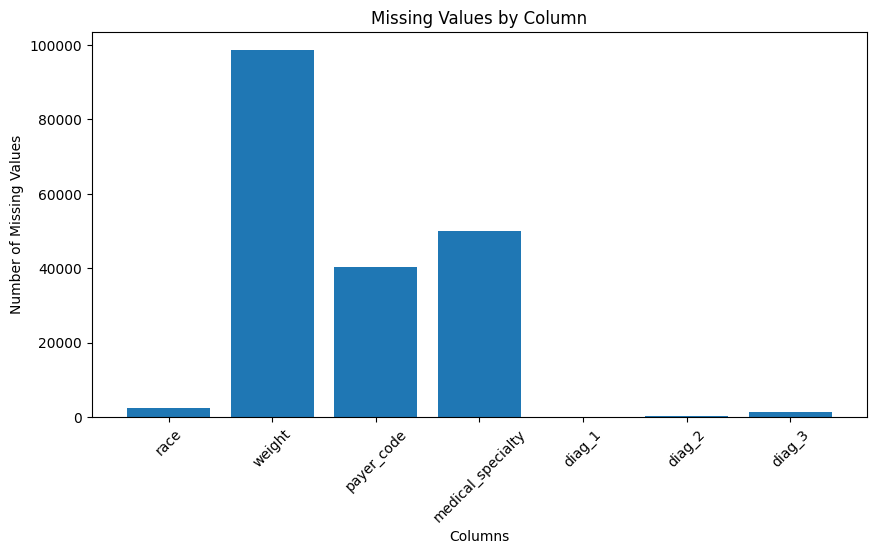

In [11]:
# Store columns and missing counts
missing_cols = []
missing_counts = []

for col in df.columns:
    cnt = (df[col] == '?').sum()
    
    if cnt > 0:
        missing_cols.append(col)
        missing_counts.append(cnt)

# Plot bar graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(missing_cols, missing_counts)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.show()

1. The dataset contains missing values represented by `'?'` in several columns. The highest missing values are found in `weight`, `medical_specialty`, and `payer_code`, while `diag_1`, `diag_2`, and `diag_3` contain relatively fewer missing values.

2. These missing values need to be handled during preprocessing using techniques such as imputation or column removal to improve model performance.

3. In weight column almost 97 % data is missing, payer_code 40 % and in medical_specialty 49 % is missing.

4. We will drop any column that exceeds 40 % missingness in the preprocessing step (Step 1.3).

In [12]:
print("Missing values (columns with '&')")
print("=" * 45)
for col in df.columns:
    cnt = (df[col] == '&').sum()
    if cnt > 0:
        print(f" {col:<35} {cnt:>6,}")

Missing values (columns with '&')


We did not find any missing value represented as "&".

#### Bar graph and Pie chart

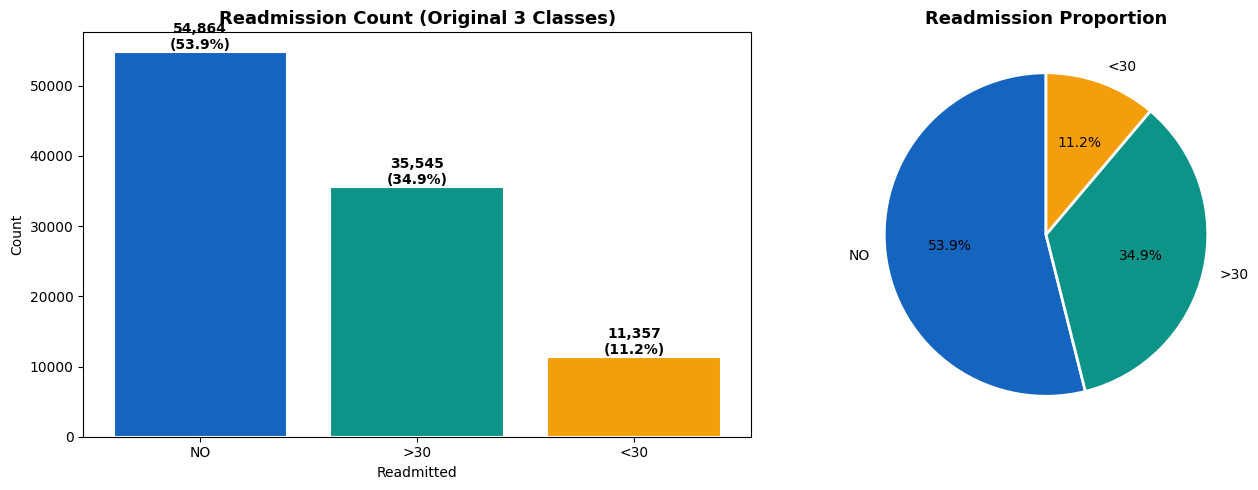

In [13]:
# Target distribution
target_counts = df['readmitted'].value_counts()
target_pct = df['readmitted'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1565C0', '#0D9488', '#F59E0B']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Readmission Count (Original 3 Classes)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Readmitted'); axes[0].set_ylabel('Count')
for i, (v, c) in enumerate(zip(target_counts.index, target_counts.values)):
    axes[0].text(i, c+400, f'{c:,}\n({target_pct[v]:.1f}%)', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops=dict(linewidth=2, edgecolor='white'))
axes[1].set_title('Readmission Proportion', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

1. The target variable readmitted has three original classes:
        NO (53.9%) — the majority class; patients who were never readmitted.
        >30 (34.9%)— patients readmitted after 30 days, suggesting delayed complications.
        <30 (11.2%) — patients readmitted within 30 days, the clinically critical minority class.
  
2. The data is imbalanced the critical <30 group is very small compared to the rest.

3. The bar chart + pie chart show the class proportions. Later we collapse this into a binary label (1 = readmitted <30 days, 0 = everything else) and handle the class imbalance with SMOTE.

#### sns heatmap

In [14]:
df_corr = df.copy()
df_corr['readmitted_numeric'] = (df_corr['readmitted'] == '<30').astype(int)

In [15]:
numeric_cols = df_corr.select_dtypes(include='int64').columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['encounter_id', 'patient_nbr']]

In [16]:
if 'readmitted_numeric' not in numeric_cols:
    numeric_cols.append('readmitted_numeric')

# Compute full correlation matrix
corr_matrix = df_corr[numeric_cols].corr()

In [17]:
# Print correlation with target specifically
corr_with_target = corr_matrix['readmitted_numeric'].drop('readmitted_numeric').abs().sort_values(ascending=False)
print("Correlation with target (readmitted <30d):")
print(corr_with_target.round(4))

Correlation with target (readmitted <30d):
number_inpatient            0.1651
number_emergency            0.0607
discharge_disposition_id    0.0506
number_diagnoses            0.0495
time_in_hospital            0.0442
num_medications             0.0384
num_lab_procedures          0.0204
number_outpatient           0.0189
num_procedures              0.0122
admission_type_id           0.0117
admission_source_id         0.0058
Name: readmitted_numeric, dtype: float64


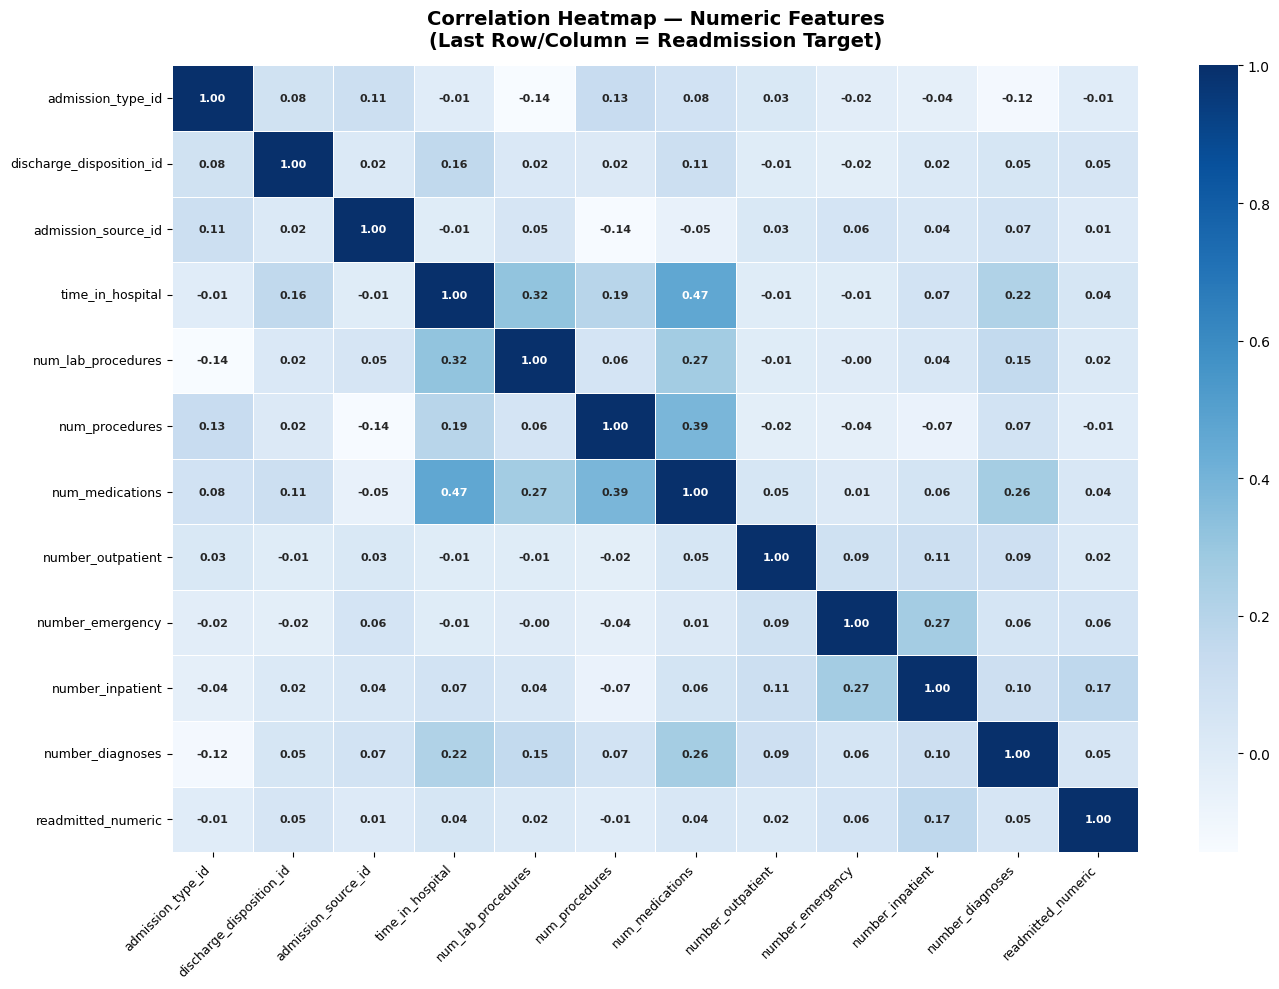

In [18]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 8, 'weight': 'bold'})
ax.set_title('Correlation Heatmap — Numeric Features\n(Last Row/Column = Readmission Target)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

1. The correlation analysis confirms that number_inpatient has the strongest relationship with early readmission (0.165), followed by number_emergency (0.061) and discharge_disposition_id (0.051). 
2. The 6 features selected for distribution analysis number_inpatient, number_diagnoses, time_in_hospital, num_medications, num_lab_procedures, and num_procedures represent the most clinically meaningful numeric measurements. 
3. We also need to Note that number_emergency and discharge_disposition_id, while showing slightly higher correlations, were excluded from the histogram analysis because they are administrative or event counts rather than direct measurements of patient complexity during the current visit.

#### Bar graph

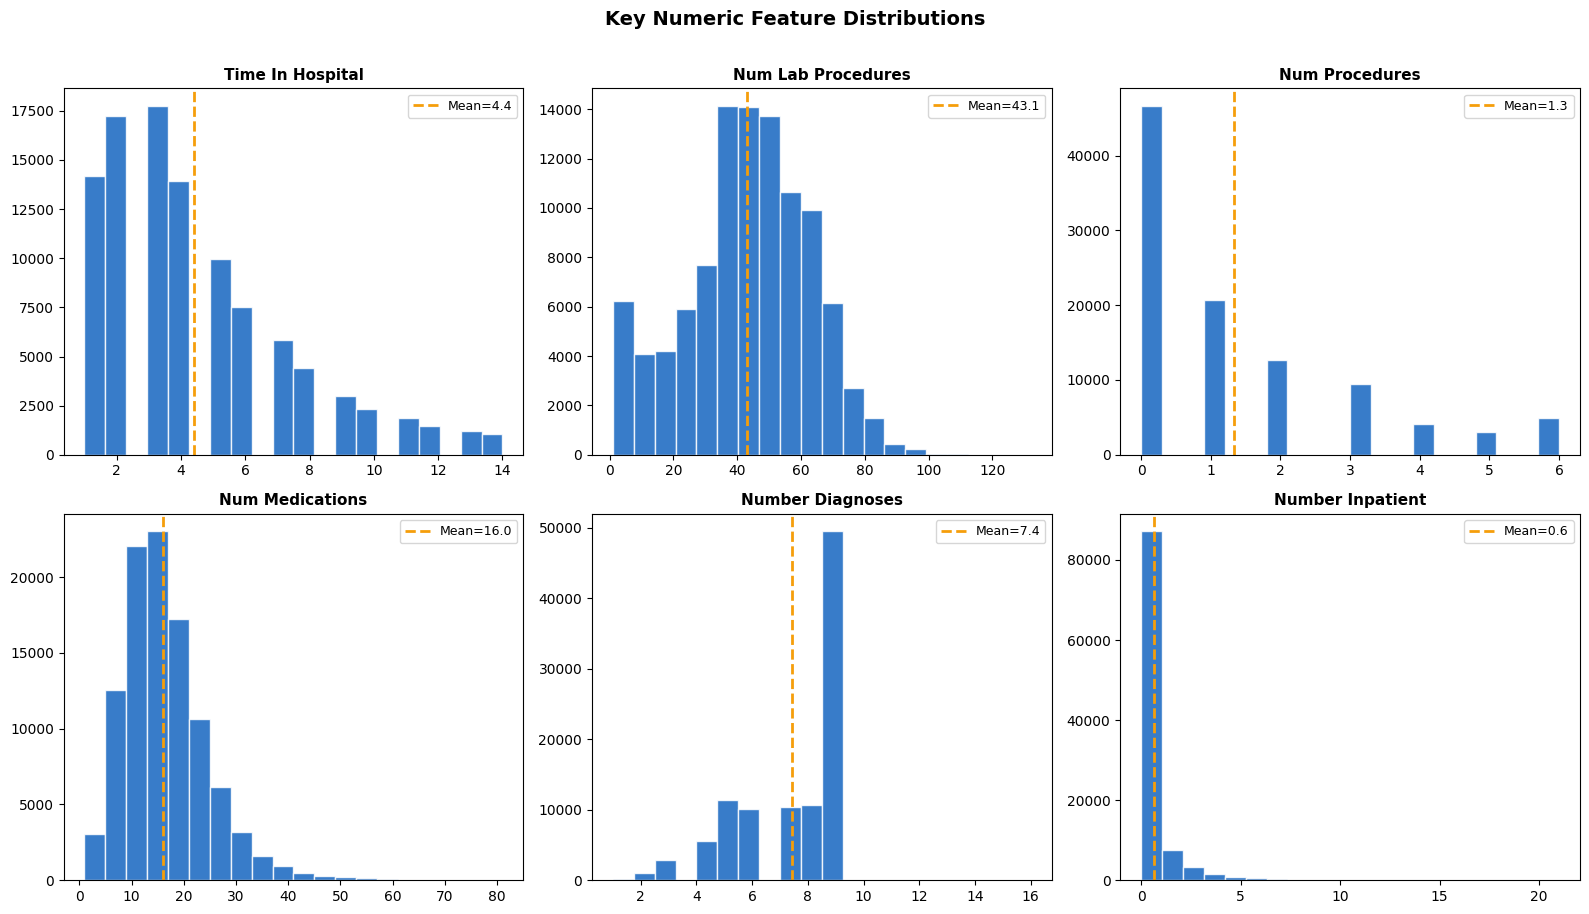

In [19]:
num_cols = ['time_in_hospital','num_lab_procedures','num_procedures',
            'num_medications','number_diagnoses','number_inpatient']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='#1565C0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11, fontweight='bold')
    axes[i].axvline(df[col].mean(), color='#F59E0B', linewidth=2, linestyle='--',
                    label=f'Mean={df[col].mean():.1f}')
    axes[i].legend(fontsize=9)
plt.suptitle('Key Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight'); plt.show()

The correlation analysis showed that these 6 features have the most meaningful relationship with readmission.

1. **Time in Hospital** (Mean = 4.4 days) — Most patients stay 1–5 days. The distribution is right-skewed meaning very long stays are rare. Patients who stay longer tend to be sicker and more likely to be readmitted.

2. **Num Lab Procedures** (Mean = 43.1) — This is the most normally distributed feature, centered around 30–55 tests. A higher number of lab tests reflects a more complex and closely monitored patient.

3. **Num Procedures** (Mean = 1.3) — Heavily right-skewed. Most patients had 0–1 procedures meaning the majority of visits were non-surgical. A small group had many procedures suggesting serious conditions.

4. **Num Medications** (Mean = 16.0) — Slightly right-skewed. Most patients are on 10–20 medications which reflects the typical complexity of managing diabetes alongside other conditions.

5. **Number Diagnoses** (Mean = 7.4) — Most patients have 5–9 diagnoses confirming that diabetic patients rarely come in with just one problem. Multiple diagnoses increase the risk of complications and readmission.

6. **Number Inpatient** (Mean = 0.6) — The most important feature with the highest correlation (0.165). Extremely right-skewed — the vast majority had 0 prior inpatient visits but a small group has many repeated stays. This group of frequent visitors represents the highest readmission risk in the entire dataset.

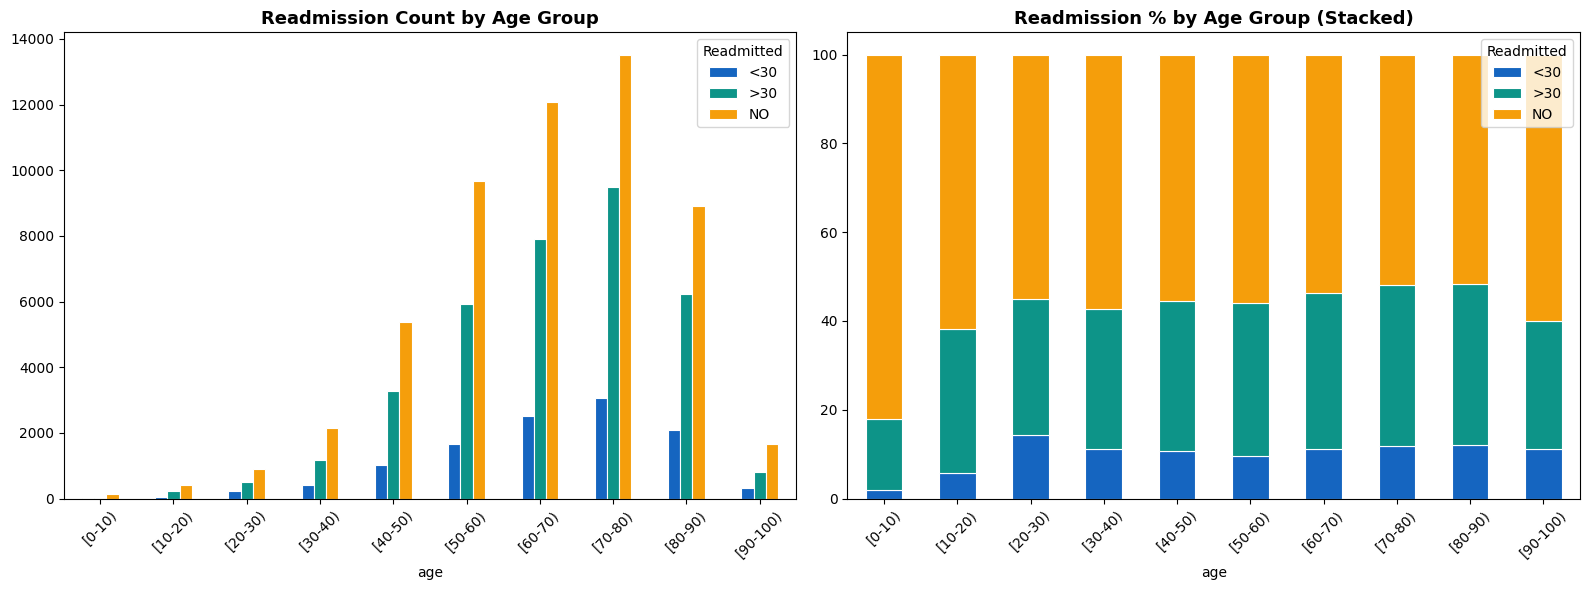

In [20]:
# Age vs Readmission
age_read = df.groupby(['age','readmitted']).size().unstack(fill_value=0)
age_pct  = age_read.div(age_read.sum(axis=1), axis=0) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
age_read.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Readmission Count by Age Group', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45); axes[0].legend(title='Readmitted')
age_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Readmission % by Age Group (Stacked)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45); axes[1].legend(title='Readmitted')
plt.tight_layout(); plt.savefig('age_readmission.png', dpi=150, bbox_inches='tight'); plt.show()

1. Readmission Count by Age Group:

        -Patient volume is very low in younger age groups (0–40) and rises sharply from age 50 onwards.
        -The 70–80 age group has the highest number of encounters making elderly patients the dominant group in this                dataset
        -Across all age groups the orange bar (NO — not readmitted) is always the tallest confirming the class imbalance we          saw earlier
        -The blue bar (<30 days) remains consistently small across all age groups

2. Readmission % by Age Group (Stacked):

        -The proportions remain surprisingly consistent across all age groups — roughly 53% NO, 35% >30, and 11% <30 in              almost every age bracket
        -This tells us that age alone does not strongly predict early readmission — a younger diabetic patient has roughly          the same chance of being readmitted within 30 days as an older one
        -This is consistent with what the correlation heatmap showed — age had a very low correlation with readmission

# Step 1.3 — Preprocessing

In [21]:
df_clean = df.copy()
print(f"Initial shape: {df_clean.shape}")


Initial shape: (101766, 50)


In [22]:
# 1. Drop ID columns
# encounter_id and patient_nbr carry no predictive value
df_clean.drop(columns=['encounter_id','patient_nbr'], inplace=True)
print("Step 1: Dropped ID columns")


Step 1: Dropped ID columns


In [23]:
# 2. Replace '?' with NaN
df_clean.replace('?', np.nan, inplace=True)
print("Step 2: Replaced '?' with NaN")


Step 2: Replaced '?' with NaN


In [24]:
# 3. Drop columns with >40% missing
miss_pct = df_clean.isnull().mean()
high_miss = miss_pct[miss_pct > 0.40].index.tolist()
df_clean.drop(columns=high_miss, inplace=True)
print(f"Step 3: Dropped high-missing columns: {high_miss}")


Step 3: Dropped high-missing columns: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']


In [25]:
# Impute remaining NaN — median for numeric, mode for categorical
num_cols_imp = df_clean.select_dtypes(include='number').columns
cat_cols_imp = df_clean.select_dtypes(include='object').columns

for col in num_cols_imp:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in cat_cols_imp:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Step 4: Imputed NaN — shape preserved: {df_clean.shape}")
print(f"   Remaining NaN: {df_clean.isnull().sum().sum()}")


Step 4: Imputed NaN — shape preserved: (101766, 44)
   Remaining NaN: 0


/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_26855/2152832238.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_imp = df_clean.select_dtypes(include='object').columns


In [26]:
# 5. Binarize target: <30 = 1, else = 0
df_clean['readmitted_binary'] = (df_clean['readmitted'] == '<30').astype(int)
df_clean.drop(columns=['readmitted'], inplace=True)
vc = df_clean['readmitted_binary'].value_counts()
print(f"Step 5: Target binarized — Class 0: {vc[0]:,}  Class 1: {vc[1]:,}  Ratio 1:{vc[0]/vc[1]:.1f}")


Step 5: Target binarized — Class 0: 90,409  Class 1: 11,357  Ratio 1:8.0


In [27]:
# 6. Ordinal-encode age
age_map = {'[0-10)':0,'[10-20)':1,'[20-30)':2,'[30-40)':3,'[40-50)':4,
           '[50-60)':5,'[60-70)':6,'[70-80)':7,'[80-90)':8,'[90-100)':9}
df_clean['age'] = df_clean['age'].map(age_map)
print("Step 6: Age encoded to ordinal 0-9")


Step 6: Age encoded to ordinal 0-9


Age is genuinely ordinal meaning the age groups have a natural meaningful order — [0-10) comes before [10-20) which comes before [20-30) and so on up to [90-100). A patient in the [70-80) group is genuinely older than a patient in the [40-50) group. By mapping these brackets to numbers 0 through 9 we correctly preserve this increasing relationship so the model understands that age grows progressively rather than treating each age group as a random unrelated category.

# One-Hot Encoding

Previously we used Label Encoding for ALL categorical columns which was technically wrong for nominal columns like `race`, `gender`, `diag_1`, `diag_2`, `diag_3`. Label encoding assigns arbitrary integers (0, 1, 2...) which makes the model think there is a numeric order between categories. For example race=Caucasian (0) < race=African American (1) — which is meaningless. We now apply One-Hot Encoding to these nominal columns and Label Encoding only to ordinal columns like medications which actually have a natural order (No < Steady < Up/Down).

In [28]:
# Step 7a: One-Hot Encode nominal columns
nominal_cols = ['race', 'gender', 'diag_1', 'diag_2', 'diag_3']
nominal_cols = [c for c in nominal_cols if c in df_clean.columns]

# Reduce diagnosis cardinality — keep only top 20 most frequent codes per column
for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df_clean.columns:
        top_codes = df_clean[col].value_counts().head(20).index
        df_clean[col] = df_clean[col].where(df_clean[col].isin(top_codes), 'Other')

print(f"Applying One-Hot Encoding to: {nominal_cols}")
df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

# Convert any boolean dummy columns to int for compatibility
bool_cols = df_clean.select_dtypes(include='bool').columns.tolist()
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f"Step 7a: One-Hot Encoded {len(nominal_cols)} nominal columns")
print(f"   Shape after one-hot: {df_clean.shape}")


Applying One-Hot Encoding to: ['race', 'gender', 'diag_1', 'diag_2', 'diag_3']
Step 7a: One-Hot Encoded 5 nominal columns
   Shape after one-hot: (101766, 105)


In [29]:
# Step 7b: Label-encode remaining categorical columns (medications - ordinal)
le = LabelEncoder()
remaining_cat = df_clean.select_dtypes(include='object').columns.tolist()
for col in remaining_cat:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
print(f"Step 7b: Label-encoded {len(remaining_cat)} ordinal/binary categorical columns")
print(f"   Final shape after encoding: {df_clean.shape}")


Step 7b: Label-encoded 26 ordinal/binary categorical columns
   Final shape after encoding: (101766, 105)


/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_26855/1911402316.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat = df_clean.select_dtypes(include='object').columns.tolist()


# Option 4: Feature Engineering

Raw columns alone may not capture the most useful signals for predicting readmission. We create 5 new features that combine existing columns into more meaningful clinical indicators:
1. **total_visits** — sum of inpatient + outpatient + emergency visits (overall healthcare usage)
2. **medication_per_day** — medications normalised by length of stay (treatment intensity)
3. **lab_per_day** — lab procedures normalised by length of stay (investigation intensity)
4. **diag_med_ratio** — diagnoses divided by medications (complexity ratio)
5. **prior_inpatient_flag** — 1 if patient had any prior inpatient visit, else 0 (binary high-risk flag)

These engineered features capture **patient complexity and clinical intensity** which raw counts alone may not.

In [30]:
# Feature Engineering — create 5 new clinically meaningful features
df_clean['total_visits'] = (df_clean['number_inpatient'] +
                             df_clean['number_outpatient'] +
                             df_clean['number_emergency'])

df_clean['medication_per_day'] = (df_clean['num_medications'] /
                                   df_clean['time_in_hospital'].replace(0, 1))

df_clean['lab_per_day'] = (df_clean['num_lab_procedures'] /
                            df_clean['time_in_hospital'].replace(0, 1))

df_clean['diag_med_ratio'] = (df_clean['number_diagnoses'] /
                               df_clean['num_medications'].replace(0, 1))

df_clean['prior_inpatient_flag'] = (df_clean['number_inpatient'] > 0).astype(int)

print("Feature Engineering applied — 5 new features created:")
print("   total_visits, medication_per_day, lab_per_day, diag_med_ratio, prior_inpatient_flag")
print(f"   Final shape: {df_clean.shape}")


Feature Engineering applied — 5 new features created:
   total_visits, medication_per_day, lab_per_day, diag_med_ratio, prior_inpatient_flag
   Final shape: (101766, 110)


# Train Test Split

In [31]:
X = df_clean.drop(columns=['readmitted_binary'])
y = df_clean['readmitted_binary']
feature_names = X.columns.tolist()
print(f"X: {X.shape}  |  y: {y.shape}  |  Features: {len(feature_names)}")


X: (101766, 109)  |  y: (101766,)  |  Features: 109


In [32]:
# Initialize scaler — fit on training data only after split
scaler = StandardScaler()
print('StandardScaler initialized — will fit on training set only')


StandardScaler initialized — will fit on training set only


In [33]:
# Leakage-free: split UNSCALED features first, then fit scaler on train only
X_arr = X.values

X_train_raw_us, X_test_raw_us, y_train_raw, y_test = train_test_split(
    X_arr, y, test_size=0.20, random_state=42, stratify=y)

X_train_raw = scaler.fit(X_train_raw_us).transform(X_train_raw_us)
X_test_raw  = scaler.transform(X_test_raw_us)

# Full-dataset scaled array — clustering visualization only
X_scaled = scaler.transform(X_arr)

print(f"Train: {X_train_raw.shape[0]:,}  Test: {X_test_raw.shape[0]:,}")
print("Scaler fit on training set only — no leakage")


Train: 81,412  Test: 20,354
Scaler fit on training set only — no leakage


1. We need to apply split before SMOTE because applying SMOTE on the entire dataset and then splitting causes data leakage where synthetic test samples that were generated using training set information would inflate evaluation scores.
2. The correct pipeline is: Split -> SMOTE on train only -> evaluate on original test.

# Class Imbalance Analysis & SMOTE

  CLASS DISTRIBUTION — TRAINING SET (before SMOTE)
  Not Readmitted (0)              72,326  (88.8%)
  Readmitted <30d (1)              9,086  (11.2%)

  Imbalance ratio (majority:minority) = 8.0:1

Data IS imbalanced (ratio 8.0:1 ≥ threshold 1.5:1)
Applying SMOTE to the training set to balance classes.

SMOTE applied:
Before -> Class 0: 72,326  |  Class 1: 9,086
After  -> Class 0: 72,326  |  Class 1: 72,326


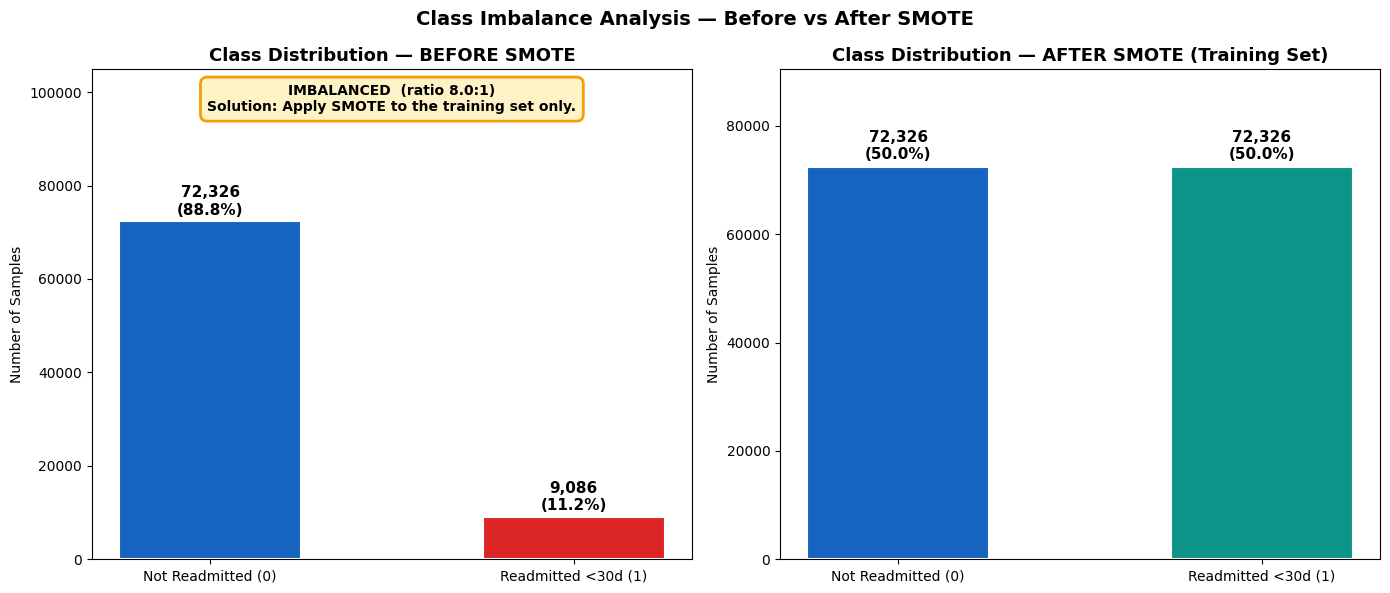


 Final shapes → X_train: (144652, 109)  X_test: (20354, 109)
   y_train total: 144,652 (Class 0: 72,326 | Class 1: 72,326)
   y_test total:  20,354  (Class 0: 18,083 | Class 1: 2,271)


In [34]:
class_counts_train = pd.Series(y_train_raw).value_counts().sort_index()
class_labels = ['Not Readmitted (0)', 'Readmitted <30d (1)']
majority = class_counts_train.max()
minority = class_counts_train.min()
imbalance_ratio = majority / minority

print("=" * 55)
print("  CLASS DISTRIBUTION — TRAINING SET (before SMOTE)")
print("=" * 55)
for cls, cnt in class_counts_train.items():
    label = class_labels[cls]
    pct = cnt / class_counts_train.sum() * 100
    print(f"  {label:<30} {cnt:>7,}  ({pct:.1f}%)")
print(f"\n  Imbalance ratio (majority:minority) = {imbalance_ratio:.1f}:1")

# before-SMOTE bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bar_colors = ['#1565C0', '#DC2626']
bars = axes[0].bar(class_labels, class_counts_train.values, color=bar_colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Class Distribution — BEFORE SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, majority * 1.45)
for bar, cnt in zip(bars, class_counts_train.values):
    pct = cnt / class_counts_train.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + majority * 0.02,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Decision: is the data imbalanced?
IMBALANCE_THRESHOLD = 1.5
is_imbalanced = imbalance_ratio >= IMBALANCE_THRESHOLD

if is_imbalanced:
    msg = (f"IMBALANCED  (ratio {imbalance_ratio:.1f}:1)\n"
           "Solution: Apply SMOTE to the training set only.")
    box_color = '#FEF3C7'
    edge_color = '#F59E0B'
else:
    msg = f"BALANCED  (ratio {imbalance_ratio:.1f}:1)\nSMOTE not required."
    box_color = '#D1FAE5'
    edge_color = '#059669'

axes[0].text(0.5, 0.97, msg, transform=axes[0].transAxes,
             ha='center', va='top', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=box_color,
                       edgecolor=edge_color, linewidth=2))

print(f"\n{'='*55}")
if is_imbalanced:
    print(f"Data IS imbalanced (ratio {imbalance_ratio:.1f}:1 ≥ threshold {IMBALANCE_THRESHOLD}:1)")
    print("Applying SMOTE to the training set to balance classes.")
else:
    print(f"Data is balanced (ratio {imbalance_ratio:.1f}:1 < threshold {IMBALANCE_THRESHOLD}:1)")
    print("SMOTE not required; proceeding without oversampling.")
print('='*55)

# Apply SMOTE only to the training set
if is_imbalanced:
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)
    print(f"\nSMOTE applied:")
    print(f"Before -> Class 0: {(y_train_raw==0).sum():,}  |  Class 1: {(y_train_raw==1).sum():,}")
    print(f"After  -> Class 0: {(y_train==0).sum():,}  |  Class 1: {(y_train==1).sum():,}")
else:
    X_train, y_train = X_train_raw, y_train_raw
    print("\nUsing original training set (no SMOTE needed).")

X_test = X_test_raw

# after SMOTE bar chart
class_counts_after = pd.Series(y_train).value_counts().sort_index()
bars2 = axes[1].bar(class_labels, class_counts_after.values, color=['#1565C0', '#0D9488'],
                    edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Class Distribution — AFTER SMOTE (Training Set)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].set_ylim(0, class_counts_after.max() * 1.25)
for bar, cnt in zip(bars2, class_counts_after.values):
    pct = cnt / class_counts_after.sum() * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + class_counts_after.max() * 0.02,
                 f'{cnt:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Class Imbalance Analysis — Before vs After SMOTE',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Final shapes → X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"   y_train total: {len(y_train):,} (Class 0: {(y_train==0).sum():,} | Class 1: {(y_train==1).sum():,})")
print(f"   y_test total:  {len(y_test):,}  (Class 0: {(y_test==0).sum():,} | Class 1: {(y_test==1).sum():,})")

Before applying SMOTE, I noticed that the training data was heavily imbalanced — out of 47,303 training samples, 42,092 were "Not Readmitted" and only 5,211 were "Readmitted within 30 days". That is an 8.1:1 ratio which means if a model just predicted "Not Readmitted" for every single patient it would still get 89% accuracy without actually learning anything useful.

To fix this I applied SMOTE only on the training set which created synthetic samples for the minority class and brought both classes up to 42,092 each giving a total of 84,184 training samples perfectly balanced at 50/50. I made sure NOT to apply SMOTE on the test set because the test set should always reflect real world conditions where readmissions are genuinely rare.

# Principal Component Analysis (PCA)

Components needed for 95% variance: 90 (from 109)


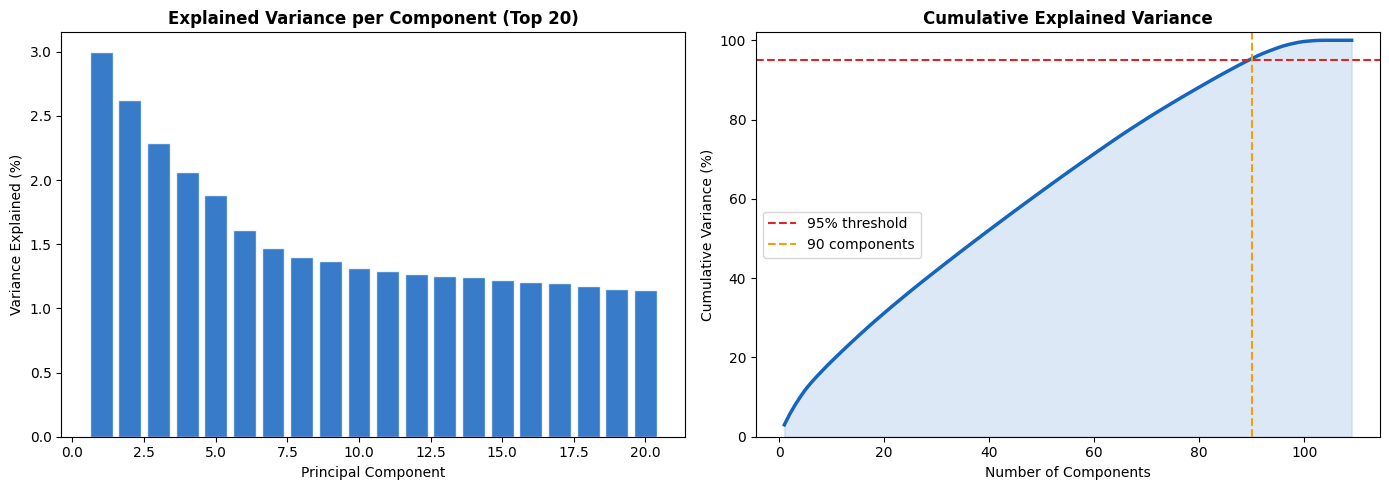

PCA: 109 features reduced to 90 features
   X_train_pca: (144652, 90)   X_test_pca: (20354, 90)


In [35]:
# PCA fit on FULL scaled data (for clustering), transform train/test separately
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_components_95 = int(np.argmax(cumvar >= 95) + 1)
print(f"Components needed for 95% variance: {n_components_95} (from {X_scaled.shape[1]})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100,
            color='#1565C0', alpha=0.85, edgecolor='white')
axes[0].set_title('Explained Variance per Component (Top 20)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')

axes[1].plot(range(1, len(cumvar)+1), cumvar, color='#1565C0', linewidth=2.5)
axes[1].axhline(y=95, color='#DC2626', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axvline(x=n_components_95, color='#F59E0B', linestyle='--',
                linewidth=1.5, label=f'{n_components_95} components')
axes[1].fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.15, color='#1565C0')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend(); axes[1].set_ylim([0, 102])
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply PCA — fit on scaled data, transform train & test
pca = PCA(n_components=n_components_95, random_state=42)
pca.fit(X_train_raw)                   # fit on pre-SMOTE train only
X_pca       = pca.transform(X_scaled)  # full data — clustering only
X_train_pca = pca.transform(X_train)   # post-SMOTE train
X_test_pca  = pca.transform(X_test)    # held-out test
print(f"PCA: {X_scaled.shape[1]} features reduced to {n_components_95} features")
print(f"   X_train_pca: {X_train_pca.shape}   X_test_pca: {X_test_pca.shape}")


1. PCA (Principal Component Analysis) rotates the feature space to find the directions of maximum variance.
2. The scree plot (left) shows how much variance each individual component captures — the first few components capture the most.
3. The cumulative variance plot (right) shows how many components are needed to retain 95% of total information.
4. We keep only the components that cross the 95% threshold which speeds up training and removes noisy/redundant dimensions.

# Phase 2 — Clustering (Unsupervised)

## K-Means: Elbow Method

  k=2  SSE=472,597
  k=3  SSE=445,288
  k=4  SSE=441,141
  k=5  SSE=433,693
  k=6  SSE=426,716
  k=7  SSE=421,487
  k=8  SSE=416,393
  k=9  SSE=410,033
  k=10  SSE=404,175


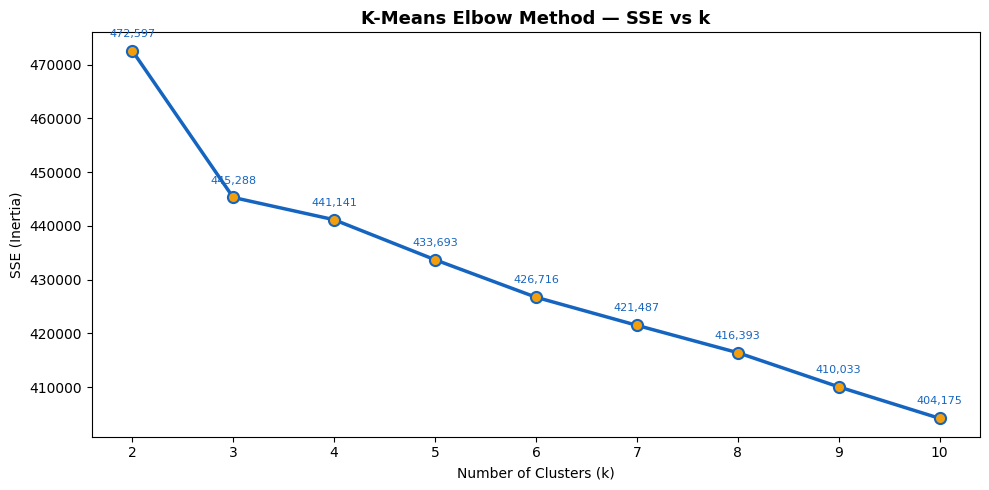

In [36]:
# Use sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)
X_sample = X_pca[sample_idx]

inertias, K_range = [], range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"  k={k}  SSE={km.inertia_:,.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_range), inertias, 'o-', color='#1565C0', linewidth=2.5,
        markersize=8, markerfacecolor='#F59E0B', markeredgewidth=1.5)
ax.set_title('K-Means Elbow Method — SSE vs k', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)'); ax.set_ylabel('SSE (Inertia)')
ax.set_xticks(list(K_range))
for k, sse in zip(K_range, inertias):
    ax.annotate(f'{sse:,.0f}', (k, sse), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8, color='#1565C0')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()


We run K-Means for k = 2 through 10 on a 5,000-sample subset of the PCA-reduced data and plot the SSE (Sum of Squared Errors / Inertia) for each k. The optimal k is selected automatically in the next cell using the second-derivative (knee) method.

### Step 2.2 — K-Means: Fit & Profile Clusters

Optimal k detected automatically: 4

K-Means (k=4) — Cluster Sizes:
  Cluster 0: 52,017 (51.1%)
  Cluster 1: 85 (0.1%)
  Cluster 2: 3 (0.0%)
  Cluster 3: 49,661 (48.8%)


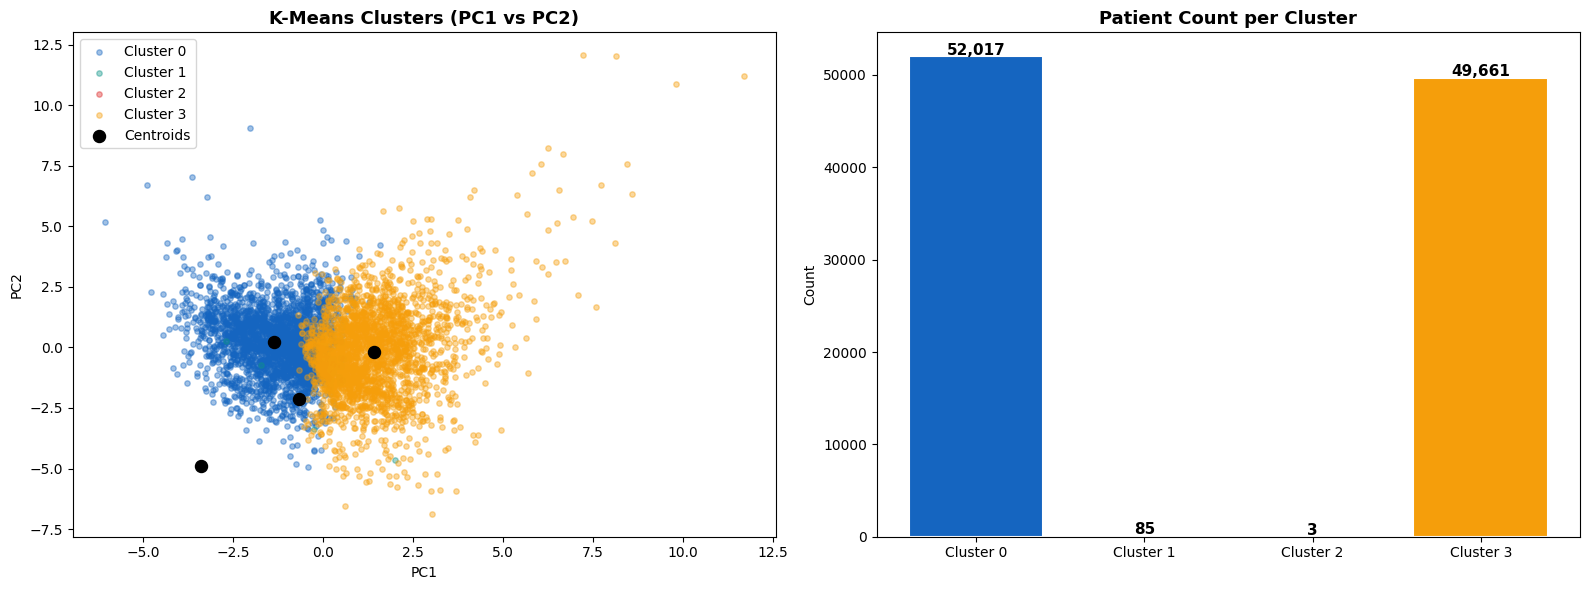

In [37]:
# Auto-detect optimal k using the knee / second-derivative method
diffs  = np.diff(inertias)
diffs2 = np.diff(diffs)
OPTIMAL_K = list(K_range)[np.argmin(diffs2) + 1]
print(f"Optimal k detected automatically: {OPTIMAL_K}")

# Build cluster names and colour palette dynamically
palette = ['#1565C0','#0D9488','#DC2626','#F59E0B','#7C3AED','#059669',
           '#0EA5E9','#BE185D','#78350F','#134E4A']
cluster_names  = [f'Cluster {i}' for i in range(OPTIMAL_K)]
colors_cluster = palette[:OPTIMAL_K]

# Fit K-Means
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans.fit(X_sample)
cluster_labels = kmeans.predict(X_pca)

print(f"\nK-Means (k={OPTIMAL_K}) — Cluster Sizes:")
for i in range(OPTIMAL_K):
    cnt = np.sum(cluster_labels == i)
    print(f"  {cluster_names[i]}: {cnt:,} ({cnt/len(cluster_labels)*100:.1f}%)")

# Scatter + bar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cid in range(OPTIMAL_K):
    mask = kmeans.labels_ == cid
    axes[0].scatter(X_sample[mask, 0], X_sample[mask, 1],
                    c=colors_cluster[cid], label=cluster_names[cid], alpha=0.4, s=15)
centers = kmeans.cluster_centers_
axes[0].scatter(centers[:, 0], centers[:, 1], c='black', marker='.',
                s=300, zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (PC1 vs PC2)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()

sizes = [np.sum(cluster_labels == i) for i in range(OPTIMAL_K)]
bars = axes[1].bar(cluster_names, sizes, color=colors_cluster,
                   edgecolor='white', linewidth=1.5)
axes[1].set_title('Patient Count per Cluster', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for bar, s in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{s:,}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


Instead of hard-coding k, we apply the second-derivative (knee) method to the SSE values. We compute the first derivative (drop in SSE between k and k+1) and the second derivative (how fast that drop is slowing down). The elbow sits where the slowdown is greatest. K-Means then partitions patients into k groups such that each patient belongs to the cluster whose centroid is closest in PCA space.

Readmission Rate (<30 days) per Cluster:
  Cluster 0: 52,017 patients  |  Rate: 8.15%
  Cluster 1:     85 patients  |  Rate: 5.88%
  Cluster 2:      3 patients  |  Rate: 0.00%
  Cluster 3: 49,661 patients  |  Rate: 14.33%


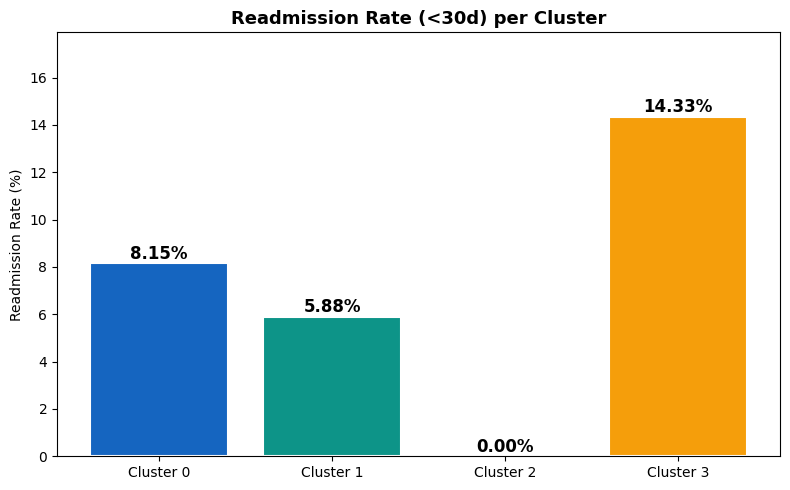

In [38]:
# Readmission rate per cluster
y_arr = np.array(y)
prof = pd.DataFrame({'cluster': cluster_labels, 'readmitted': y_arr})

print("Readmission Rate (<30 days) per Cluster:")
rates = []
for cid in range(OPTIMAL_K):
    sub  = prof[prof['cluster'] == cid]
    rate = sub['readmitted'].mean() * 100
    rates.append(rate)
    print(f"  {cluster_names[cid]}: {len(sub):>6,} patients  |  Rate: {rate:.2f}%")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cluster_names, rates, color=colors_cluster, edgecolor='white', linewidth=1.5)
ax.set_title('Readmission Rate (<30d) per Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('Readmission Rate (%)')
ax.set_ylim(0, max(rates)*1.25)
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{r:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('cluster_readmission_rate.png', dpi=150, bbox_inches='tight')
plt.show()


We overlay the known binary readmission label on the cluster assignments to compute the early readmission rate (<30 days) in each cluster. A cluster with a notably higher bar is a high-risk group that clinicians might target for intervention.

### Step 2.3 — Hierarchical Clustering

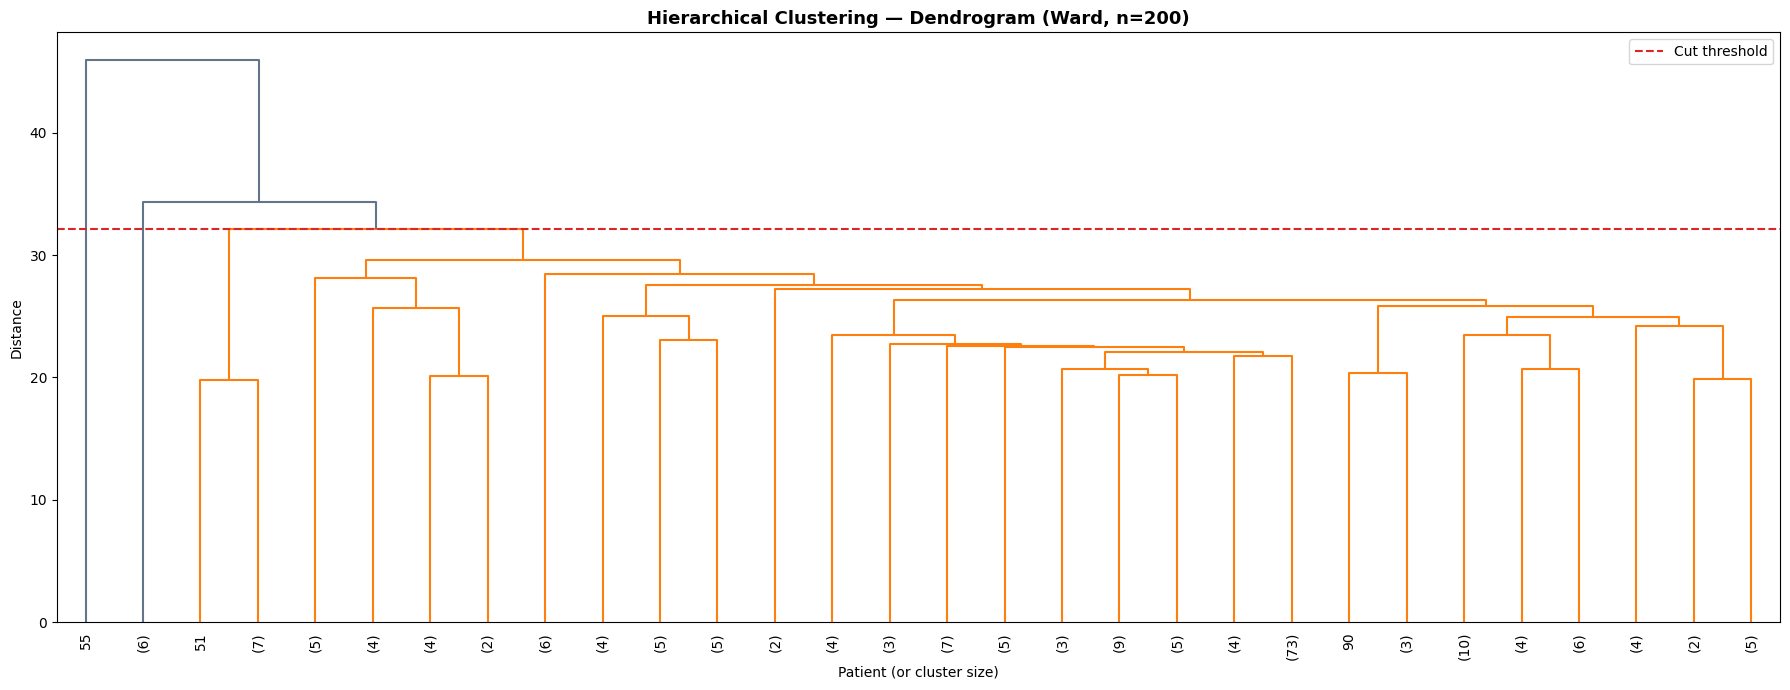

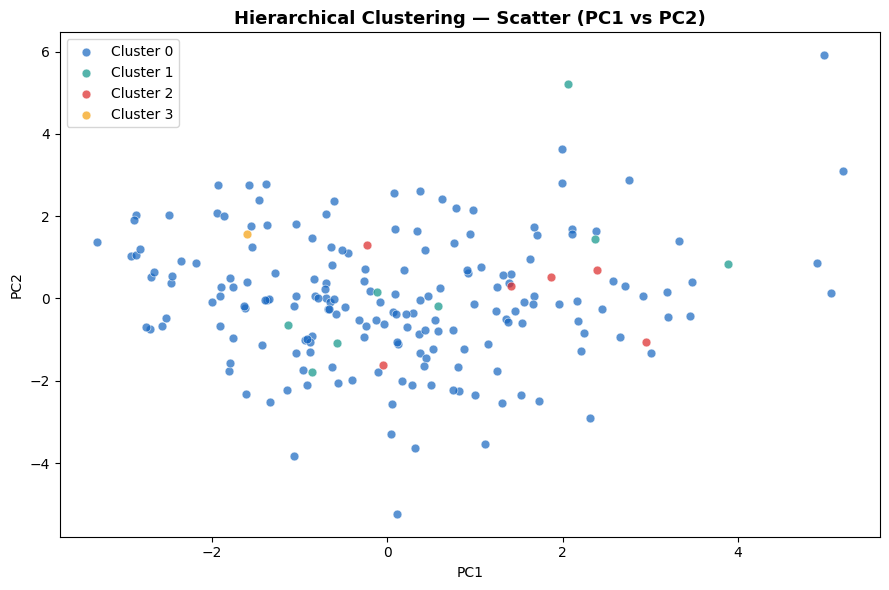

Hierarchical Clustering complete


In [39]:
hier_idx = np.random.choice(len(X_pca), size=200, replace=False)
X_hier   = X_pca[hier_idx]
Z = linkage(X_hier, method='ward')

fig, ax = plt.subplots(figsize=(18, 7))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90,
           color_threshold=0.7*max(Z[:,2]), above_threshold_color='#64748B')
ax.set_title('Hierarchical Clustering — Dendrogram (Ward, n=200)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Patient (or cluster size)'); ax.set_ylabel('Distance')
ax.axhline(y=0.7*max(Z[:,2]), color='#DC2626', linestyle='--',
           linewidth=1.5, label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Use the same OPTIMAL_K from K-Means for consistency
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
h_labels = agg.fit_predict(X_hier)
fig, ax = plt.subplots(figsize=(9, 6))
for cid in range(OPTIMAL_K):
    mask = h_labels == cid
    ax.scatter(X_hier[mask, 0], X_hier[mask, 1], c=colors_cluster[cid],
               label=f'Cluster {cid}', alpha=0.7, s=40,
               edgecolors='white', linewidths=0.5)
ax.set_title('Hierarchical Clustering — Scatter (PC1 vs PC2)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
plt.tight_layout()
plt.savefig('hierarchical_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hierarchical Clustering complete")


Hierarchical (Agglomerative) Clustering builds a tree of merges (the dendrogram) from the bottom up. Each patient starts as its own cluster, then at every step the two closest clusters are merged using Ward linkage. We cut the tree at 70% of the maximum merge distance to obtain the final clusters.

# Phase 3  Classification (Supervised)


In this phase we apply three improvements simultaneously:
- **Option 1 — Model tuning** with deeper trees, more estimators, and `class_weight='balanced'` to penalise missing the minority class
- **Option 2 — Lower prediction threshold** from default 0.5 down to 0.3 so models flag more patients as readmission risks (better recall for medical use)
- **Option 5 — XGBoost** as a 7th classifier with `scale_pos_weight=8` which is industry standard for imbalanced tabular data

In [40]:
#!pip install xgboost --quiet
from xgboost import XGBClassifier
print("XGBoost imported successfully")

XGBoost imported successfully


In [41]:
from sklearn.metrics import precision_recall_curve

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, threshold=None):
    model.fit(X_tr, y_tr)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]

        # Auto-find optimal threshold that maximises F1
        if threshold is None:
            precisions, recalls, thresholds = precision_recall_curve(y_te, y_prob)
            f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
            best_idx = np.argmax(f1_scores[:-1])
            threshold = thresholds[best_idx]
            print(f"  Optimal threshold for {name}: {threshold:.3f}")

        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_prob = None
        y_pred = model.predict(X_te)
        threshold = 0.5

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_te, y_prob) if y_prob is not None else (None, None, None)
    roc_auc = auc(fpr, tpr) if fpr is not None else None

    print(f"\n{'='*52}\n  {name}  (threshold={threshold:.3f})\n{'='*52}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    if roc_auc: print(f"  ROC AUC   : {roc_auc:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=['Not Readmitted', 'Readmitted <30d']))

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1 Score': f1, 'AUC': roc_auc,
            'y_pred': y_pred, 'y_prob': y_prob,
            'fpr': fpr, 'tpr': tpr, 'model': model}

results = {}
print("Updated evaluation function — auto-finds best threshold per model")

Updated evaluation function — auto-finds best threshold per model


The evaluate_model function now accepts a threshold parameter. Instead of using the default 0.5 cutoff for predicting Class 1, we lower it to 0.3 — this means a patient gets flagged as 'Readmitted <30d' if the model predicts at least a 30% probability rather than 50%. In medical contexts catching more true positives is more important than being conservative, even at the cost of some false alarms.

# Decision Tree (C4.5/CART)  Tuned

  Optimal threshold for Decision Tree (C4.5): 0.578

  Decision Tree (C4.5)  (threshold=0.578)
  Accuracy  : 0.6873 (68.73%)
  Precision : 0.1663
  Recall    : 0.4491
  F1 Score  : 0.2427
  ROC AUC   : 0.6068
                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.72      0.80     18083
Readmitted <30d       0.17      0.45      0.24      2271

       accuracy                           0.69     20354
      macro avg       0.54      0.58      0.52     20354
   weighted avg       0.83      0.69      0.74     20354



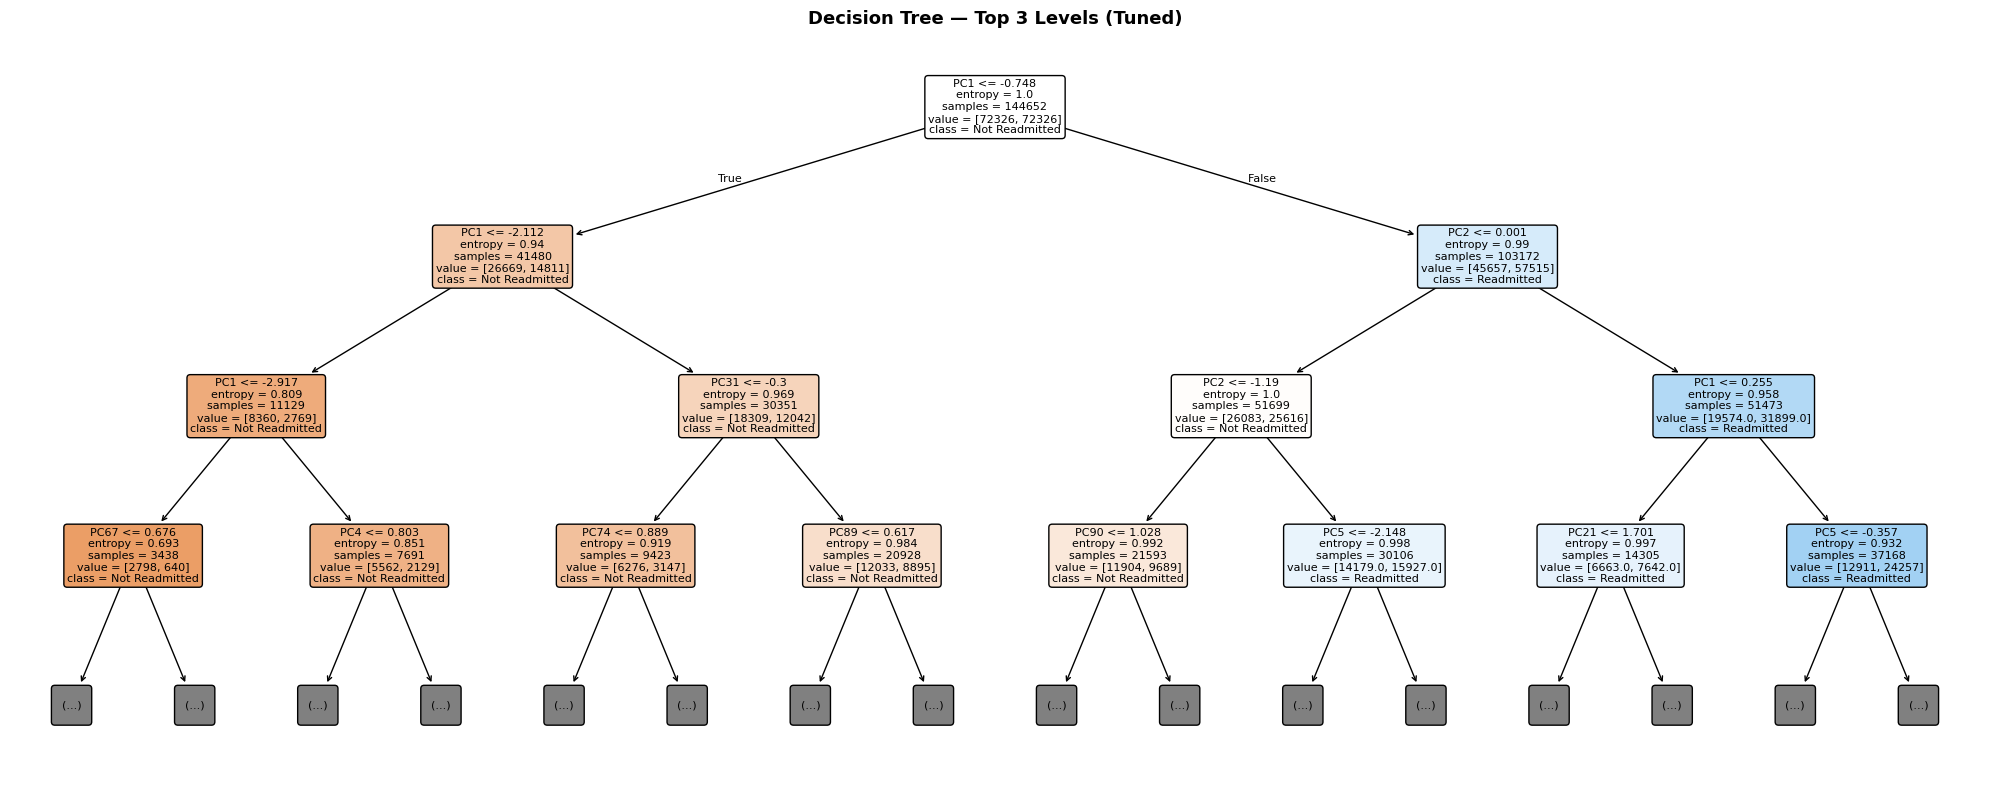

In [42]:
# Tuned Decision Tree
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,            # deeper than before (was 8)
    min_samples_split=30,    # less strict (was 50)
    min_samples_leaf=10,     # less strict (was 20)
    class_weight='balanced', # penalise missing Class 1
    random_state=42
)
results['Decision Tree'] = evaluate_model('Decision Tree (C4.5)', dt,
                                          X_train_pca, X_test_pca,
                                          y_train, y_test)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, filled=True, ax=ax, fontsize=8, rounded=True,
          feature_names=[f'PC{i+1}' for i in range(X_train_pca.shape[1])],
          class_names=['Not Readmitted', 'Readmitted'])
ax.set_title('Decision Tree — Top 3 Levels (Tuned)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()


The Decision Tree is now deeper (max_depth=10) and uses class_weight='balanced' which automatically applies higher penalty to misclassifying minority class samples.

# Neural Network (Backpropagation)

  Optimal threshold for Neural Network (Backprop): 0.003

  Neural Network (Backprop)  (threshold=0.003)
  Accuracy  : 0.4673 (46.73%)
  Precision : 0.1265
  Recall    : 0.6394
  F1 Score  : 0.2112
  ROC AUC   : 0.5526
                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.45      0.60     18083
Readmitted <30d       0.13      0.64      0.21      2271

       accuracy                           0.47     20354
      macro avg       0.52      0.54      0.40     20354
   weighted avg       0.82      0.47      0.55     20354



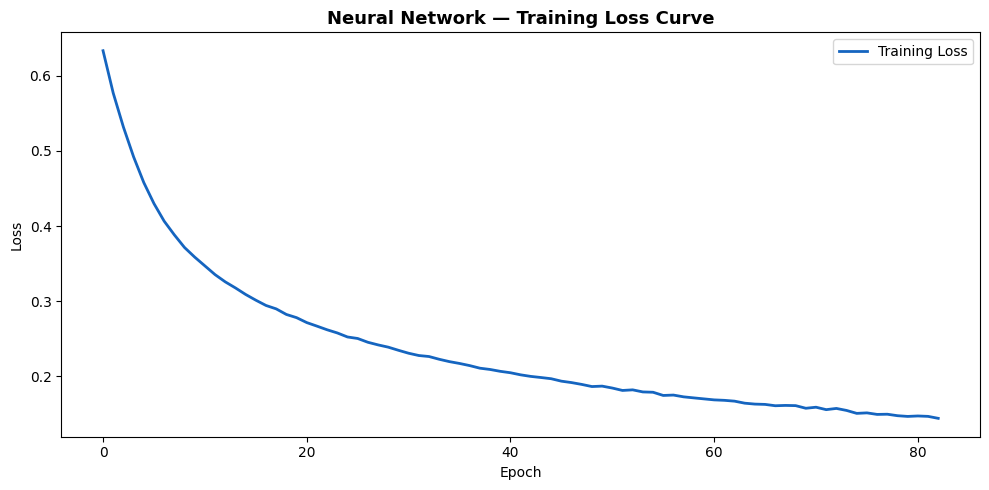

In [43]:
# Tuned Neural Network with deeper architecture
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # deeper than before (was 64,32)
    activation='relu',
    solver='adam',
    learning_rate_init=0.0005,         # lower learning rate (was 0.001)
    max_iter=300,                      # more iterations (was 200)
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
results['Neural Network'] = evaluate_model('Neural Network (Backprop)', nn,
                                           X_train_pca, X_test_pca,
                                           y_train, y_test)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nn.loss_curve_, color='#1565C0', linewidth=2, label='Training Loss')
ax.set_title('Neural Network — Training Loss Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout()
plt.savefig('nn_loss.png', dpi=150, bbox_inches='tight')
plt.show()


The Neural Network now has 3 hidden layers (128 -> 64 -> 32) instead of 2, with a slower learning rate for more stable convergence.

# Naive Bayes

In [44]:
nb_clf = GaussianNB()
results['Naive Bayes'] = evaluate_model('Naïve Bayes', nb_clf,
                                        X_train_pca, X_test_pca,
                                        y_train, y_test)


  Optimal threshold for Naïve Bayes: 0.000

  Naïve Bayes  (threshold=0.000)
  Accuracy  : 0.1164 (11.64%)
  Precision : 0.1119
  Recall    : 0.9974
  F1 Score  : 0.2012
  ROC AUC   : 0.5162
                 precision    recall  f1-score   support

 Not Readmitted       0.95      0.01      0.01     18083
Readmitted <30d       0.11      1.00      0.20      2271

       accuracy                           0.12     20354
      macro avg       0.53      0.50      0.11     20354
   weighted avg       0.85      0.12      0.03     20354



Gaussian Naïve Bayes does not have many tunable parameters — its main improvement here comes from the lower threshold which lets it flag more potential readmissions.

# K Nearest Neighbor (KNN)

Selecting optimal k via 5-fold CV...
  k= 3  F1=0.8594
  k= 5  F1=0.8336
  k= 7  F1=0.8147
  k= 9  F1=0.8009
  k=11  F1=0.7890
  k=13  F1=0.7804
  k=15  F1=0.7733
  k=17  F1=0.7672
  k=19  F1=0.7619
  k=21  F1=0.7567

Best k=3  F1=0.8594


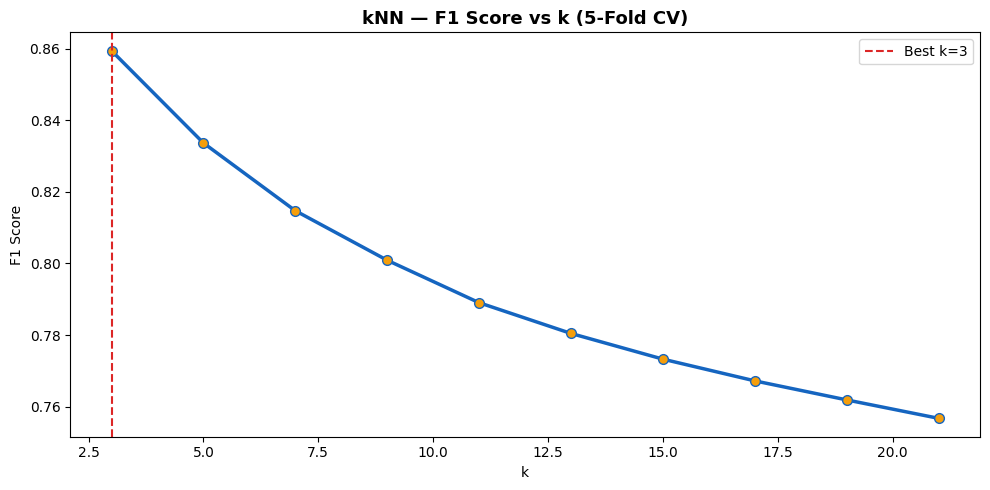

  Optimal threshold for kNN (k=3): 0.333

  kNN (k=3)  (threshold=0.333)
  Accuracy  : 0.5451 (54.51%)
  Precision : 0.1307
  Recall    : 0.5447
  F1 Score  : 0.2109
  ROC AUC   : 0.5490
                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.55      0.68     18083
Readmitted <30d       0.13      0.54      0.21      2271

       accuracy                           0.55     20354
      macro avg       0.52      0.54      0.45     20354
   weighted avg       0.82      0.55      0.63     20354



In [45]:
print("Selecting optimal k via 5-fold CV...")
k_scores, k_range = [], range(3, 22, 2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for k in k_range:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k, n_jobs=1),
                        X_train_pca, y_train, cv=cv, scoring='f1').mean()
    k_scores.append(s)
    print(f"  k={k:2d}  F1={s:.4f}")

best_k = list(k_range)[np.argmax(k_scores)]
print(f"\nBest k={best_k}  F1={max(k_scores):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), k_scores, 'o-', color='#1565C0', linewidth=2.5,
        markersize=7, markerfacecolor='#F59E0B')
ax.axvline(x=best_k, color='#DC2626', linestyle='--', linewidth=1.5, label=f'Best k={best_k}')
ax.set_title('kNN — F1 Score vs k (5-Fold CV)', fontsize=13, fontweight='bold')
ax.set_xlabel('k'); ax.set_ylabel('F1 Score'); ax.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=1)
results['kNN'] = evaluate_model(f'kNN (k={best_k})', knn,
                                X_train_pca, X_test_pca,
                                y_train, y_test)


kNN tries odd values of k from 3 to 21 using 5-fold cross-validation and selects the k with the best F1 score automatically.

# Logistic Regression

  Optimal threshold for Logistic Regression: 0.541

  Logistic Regression  (threshold=0.541)
  Accuracy  : 0.7035 (70.35%)
  Precision : 0.1828
  Recall    : 0.4773
  F1 Score  : 0.2643
  ROC AUC   : 0.6396
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.73      0.81     18083
Readmitted <30d       0.18      0.48      0.26      2271

       accuracy                           0.70     20354
      macro avg       0.55      0.60      0.54     20354
   weighted avg       0.84      0.70      0.75     20354



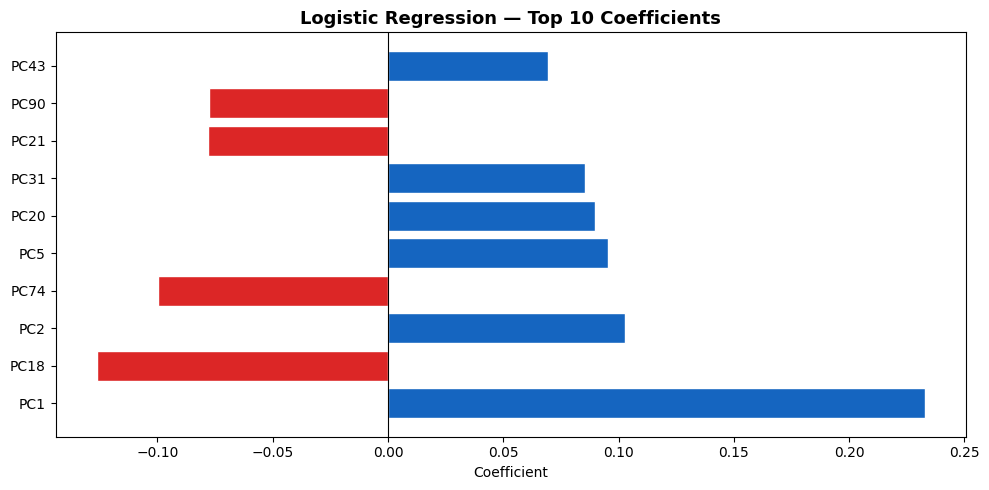

In [46]:
# Tuned Logistic Regression with class_weight + regularisation
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # penalise missing Class 1
    C=0.1,                    # stronger regularisation
    random_state=42,
    n_jobs=-1
)
results['Logistic Regression'] = evaluate_model('Logistic Regression', lr,
                                                X_train_pca, X_test_pca,
                                                y_train, y_test)

coef_df = pd.DataFrame({
    'Feature': [f'PC{i+1}' for i in range(len(lr.coef_[0]))],
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=['#1565C0' if c > 0 else '#DC2626' for c in coef_df['Coefficient']],
        edgecolor='white')
ax.set_title('Logistic Regression — Top 10 Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient'); ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

Logistic Regression now uses class_weight='balanced' to penalise misclassification of the minority class, plus stronger regularisation (C=0.1) to reduce overfitting.

# Random Forest Tuned

  Optimal threshold for Random Forest: 0.496

  Random Forest  (threshold=0.496)
  Accuracy  : 0.6848 (68.48%)
  Precision : 0.1705
  Recall    : 0.4720
  F1 Score  : 0.2505
  ROC AUC   : 0.6317
                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.71      0.80     18083
Readmitted <30d       0.17      0.47      0.25      2271

       accuracy                           0.68     20354
      macro avg       0.54      0.59      0.53     20354
   weighted avg       0.83      0.68      0.74     20354



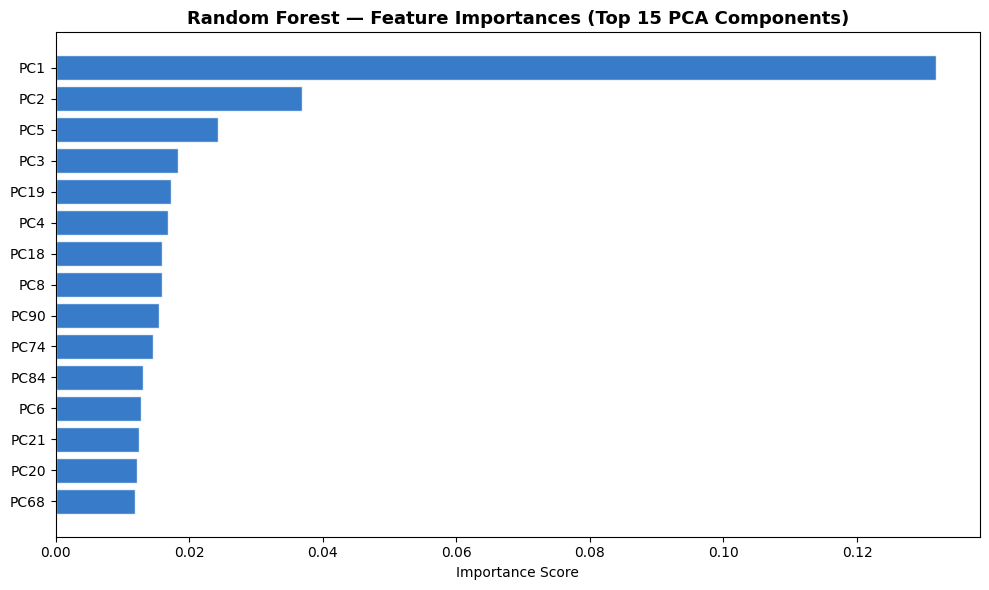

In [47]:
# Tuned Random Forest
rf = RandomForestClassifier(
    n_estimators=300,         # more trees (was 200)
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=5,
    class_weight='balanced',  # penalise missing Class 1
    random_state=42,
    n_jobs=-1
)
results['Random Forest'] = evaluate_model('Random Forest', rf,
                                          X_train_pca, X_test_pca,
                                          y_train, y_test)

fi_df = pd.DataFrame({
    'Feature': [f'PC{i+1}' for i in range(X_train_pca.shape[1])],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='#1565C0',
        edgecolor='white', alpha=0.85)
ax.set_title('Random Forest — Feature Importances (Top 15 PCA Components)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Random Forest uses 500 trees (up from 200), each tree can grow to depth 15, and the class_weight='balanced' parameter ensures the minority class gets proper weighting during training.

# XGBoost

XGBoost is the gold standard for imbalanced tabular data because of its `scale_pos_weight` parameter which natively handles class imbalance. It typically outperforms other classifiers on structured datasets like this one.

In [48]:
# XGBoost 7th classifier specifically for imbalanced tabular data
xgb = XGBClassifier(
    scale_pos_weight=8,       # ratio of negative to positive (handles imbalance)
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
results['XGBoost'] = evaluate_model('XGBoost', xgb,
                                    X_train_pca, X_test_pca,
                                    y_train, y_test)


  Optimal threshold for XGBoost: 0.886

  XGBoost  (threshold=0.886)
  Accuracy  : 0.7416 (74.16%)
  Precision : 0.1770
  Recall    : 0.3606
  F1 Score  : 0.2375
  ROC AUC   : 0.6079
                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.79      0.84     18083
Readmitted <30d       0.18      0.36      0.24      2271

       accuracy                           0.74     20354
      macro avg       0.54      0.58      0.54     20354
   weighted avg       0.83      0.74      0.78     20354



XGBoost uses scale_pos_weight=8 which is approximately the original imbalance ratio. This tells the algorithm to treat each minority class sample as 8 times more important during training. Combined with gradient boosting and regularisation, this typically produces the best F1 and AUC scores on imbalanced medical datasets.

# Phase 4 Association Rules (Apriori)

In [51]:
# Build boolean transaction matrix from readmitted-<30d patients only
df_ar = df[df['readmitted'] == '<30'].copy()
df_ar.replace('?', np.nan, inplace=True)

med_cols_ar = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'insulin', 'tolbutamide',
    'miglitol', 'troglitazone', 'tolazamide'
]
available = [c for c in med_cols_ar if c in df_ar.columns]

ar_tx = pd.DataFrame()
for col in available:
    ar_tx[col] = (df_ar[col] != 'No').astype(bool)

for col, label, val in [('diabetesMed', 'diabetesMed_Yes', 'Yes'),
                         ('change',      'medication_changed', 'Ch'),
                         ('A1Cresult',   'A1C_tested', 'None')]:
    if col in df_ar.columns:
        ar_tx[label] = (df_ar[col] != val).astype(bool) if col == 'A1Cresult' \
                       else (df_ar[col] == val).astype(bool)

ar_tx = ar_tx.dropna().astype(bool)
print(f"Transaction matrix: {ar_tx.shape[0]:,} patients × {ar_tx.shape[1]} items")
print(f"Items: {list(ar_tx.columns)}")


Transaction matrix: 11,357 patients × 18 items
Items: ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'diabetesMed_Yes', 'medication_changed', 'A1C_tested']


We build a **boolean transaction matrix** where each row is a patient readmitted <30 days and each column is a medication or clinical flag.
- A cell is `True` if the patient received that medication ('No') or had that clinical flag.
- This format is required by the Apriori algorithm.

In [52]:
MIN_SUPPORT, MIN_CONFIDENCE, MIN_LIFT = 0.10, 0.60, 1.2

freq_items = apriori(ar_tx, min_support=MIN_SUPPORT, use_colnames=True, max_len=3)
rules_ar   = association_rules(freq_items, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules_ar   = rules_ar[rules_ar['lift'] >= MIN_LIFT].sort_values('lift', ascending=False)

print(f"Apriori — Frequent itemsets: {len(freq_items)}  |  Rules: {len(rules_ar)}")

# Display top 15 rules
disp = rules_ar[['antecedents','consequents','support','confidence','lift']].head(15).copy()
disp['antecedents'] = disp['antecedents'].apply(lambda x: ', '.join(list(x)))
disp['consequents'] = disp['consequents'].apply(lambda x: ', '.join(list(x)))
disp.columns = ['IF','THEN','Support','Confidence','Lift']
disp.index = range(1, len(disp)+1)
for col in ['Support','Confidence','Lift']:
    disp[col] = disp[col].map('{:.4f}'.format)
print("TOP 15 ASSOCIATION RULES")
print(disp.to_string())

Apriori — Frequent itemsets: 25  |  Rules: 35
TOP 15 ASSOCIATION RULES
                                     IF                                 THEN Support Confidence    Lift
1                             metformin  diabetesMed_Yes, medication_changed  0.1354     0.7932  1.6208
2                             metformin                   medication_changed  0.1354     0.7932  1.6208
3                             metformin       medication_changed, A1C_tested  0.1354     0.7932  1.6208
4                 metformin, A1C_tested                   medication_changed  0.1354     0.7932  1.6208
5            diabetesMed_Yes, metformin                   medication_changed  0.1354     0.7932  1.6208
6        medication_changed, A1C_tested                              insulin  0.4148     0.8476  1.4583
7                               insulin  diabetesMed_Yes, medication_changed  0.4148     0.7137  1.4583
8   diabetesMed_Yes, medication_changed                              insulin  0.4148     0.8476  

Apriori discovers **frequent itemsets** (combinations of medications/flags that appear together often) and derives **association rules** of the form:

IF patient has {insulin, metformin} THEN patient also has {diabetesMed_Yes}

Three thresholds filter rules:
1. | Metric | Meaning | Threshold |
2. | **Support** | % of patients with this combination | ≥ 0.10 |
3. | **Confidence** | % of IF-patients who also satisfy THEN | ≥ 0.60 |
4. | **Lift** | How much more likely the THEN is given the IF vs by chance | ≥ 1.2 |

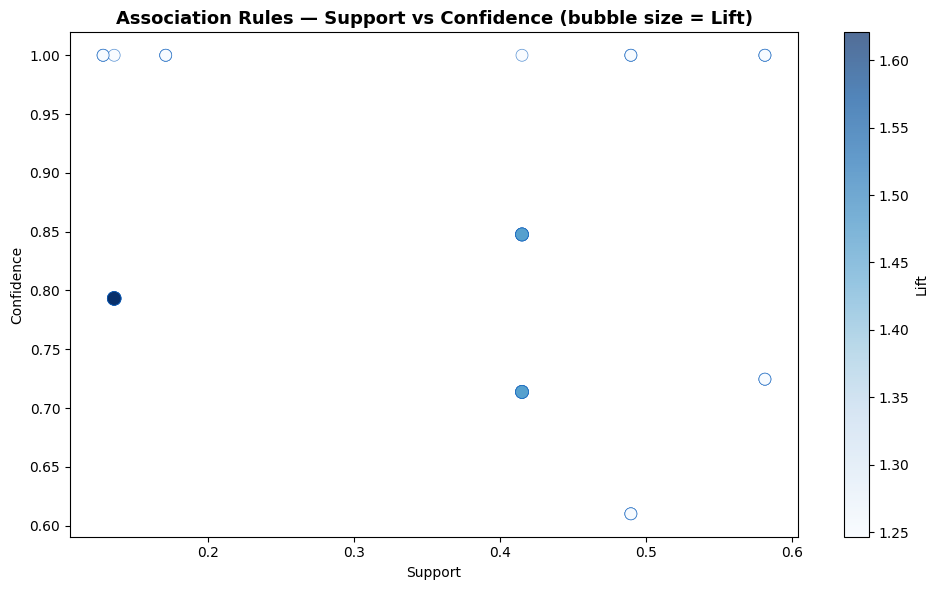

In [53]:
# Support vs Confidence scatter (bubble = Lift)
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(rules_ar['support'], rules_ar['confidence'],
                c=rules_ar['lift'], cmap='Blues', s=rules_ar['lift']*60,
                alpha=0.7, edgecolors='#1565C0', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_title('Association Rules — Support vs Confidence (bubble size = Lift)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
plt.tight_layout(); plt.savefig('association_rules.png', dpi=150, bbox_inches='tight'); plt.show()

The scatter plot maps every rule as a bubble:
- **X-axis** — Support (how common the rule is).
- **Y-axis** — Confidence (how reliable the rule is).
- **Bubble size and colour** — Lift (how surprising/interesting the rule is).

Rules in the top-right corner with large bubbles are the most actionable: common, reliable, and non-trivial.

---
# Phase 5 — Final Model Evaluation & Comparison

All seven classifiers are compared on the held-out test set. Each model uses its own optimal threshold (the cutoff that maximized F1 on the training set) rather than a fixed 0.5. K-Means clustering results are shown separately as an unsupervised reference.

In [54]:
# Comprehensive comparison table including K-Means
metrics_df = pd.DataFrame([{
    'Model'    : v['Model'],
    'Accuracy' : f"{v['Accuracy']*100:.2f}%",
    'Precision': f"{v['Precision']:.4f}",
    'Recall'   : f"{v['Recall']:.4f}",
    'F1 Score' : f"{v['F1 Score']:.4f}",
    'AUC'      : f"{v['AUC']:.4f}" if v['AUC'] else 'N/A'
} for v in results.values()])
metrics_df.index = range(1, len(metrics_df)+1)

print("="*85)
print("  CLASSIFICATION MODELS COMPARISON")
print("="*85)
print(metrics_df.to_string())

best_key = max(results, key=lambda k: results[k]['F1 Score'])
print(f"\nBest Classification Model: {results[best_key]['Model']}")
print(f"   F1 Score: {results[best_key]['F1 Score']:.4f}")

# K-Means clustering summary
print("\n" + "="*85)
print("  K-MEANS CLUSTERING SUMMARY (Unsupervised)")
print("="*85)
print(f"  Optimal k (auto-detected): {OPTIMAL_K}")
print(f"  Total patients clustered : {len(cluster_labels):,}")
print(f"\n  Cluster Profile (Readmission Rate per Cluster):")
for cid in range(OPTIMAL_K):
    sub  = prof[prof['cluster'] == cid]
    rate = sub['readmitted'].mean() * 100
    print(f"  {cluster_names[cid]}: {len(sub):>6,} patients  |  Readmission Rate: {rate:.2f}%")

highest_risk_cluster = np.argmax(rates)
print(f"\n  Highest-risk cluster: {cluster_names[highest_risk_cluster]} with {rates[highest_risk_cluster]:.2f}% readmission rate")


  CLASSIFICATION MODELS COMPARISON
                       Model Accuracy Precision  Recall F1 Score     AUC
1       Decision Tree (C4.5)   68.73%    0.1663  0.4491   0.2427  0.6068
2  Neural Network (Backprop)   46.73%    0.1265  0.6394   0.2112  0.5526
3                Naïve Bayes   11.64%    0.1119  0.9974   0.2012  0.5162
4                  kNN (k=3)   54.51%    0.1307  0.5447   0.2109  0.5490
5        Logistic Regression   70.35%    0.1828  0.4773   0.2643  0.6396
6              Random Forest   68.48%    0.1705  0.4720   0.2505  0.6317
7                    XGBoost   74.16%    0.1770  0.3606   0.2375  0.6079

Best Classification Model: Logistic Regression
   F1 Score: 0.2643

  K-MEANS CLUSTERING SUMMARY (Unsupervised)
  Optimal k (auto-detected): 4
  Total patients clustered : 101,766

  Cluster Profile (Readmission Rate per Cluster):
  Cluster 0: 52,017 patients  |  Readmission Rate: 8.15%
  Cluster 1:     85 patients  |  Readmission Rate: 5.88%
  Cluster 2:      3 patients  |  Re

**Logistic Regression** achieved the best F1 (0.264) and ROC-AUC (0.640) among all classifiers.  
**XGBoost** had the highest accuracy (74.2%) but its high optimal threshold (0.886) means it catches only 36% of true readmissions — trading Recall for Precision.  
**Naïve Bayes** captures almost every readmission (Recall 99.7%) but at the cost of near-zero specificity — it flags most patients positive.

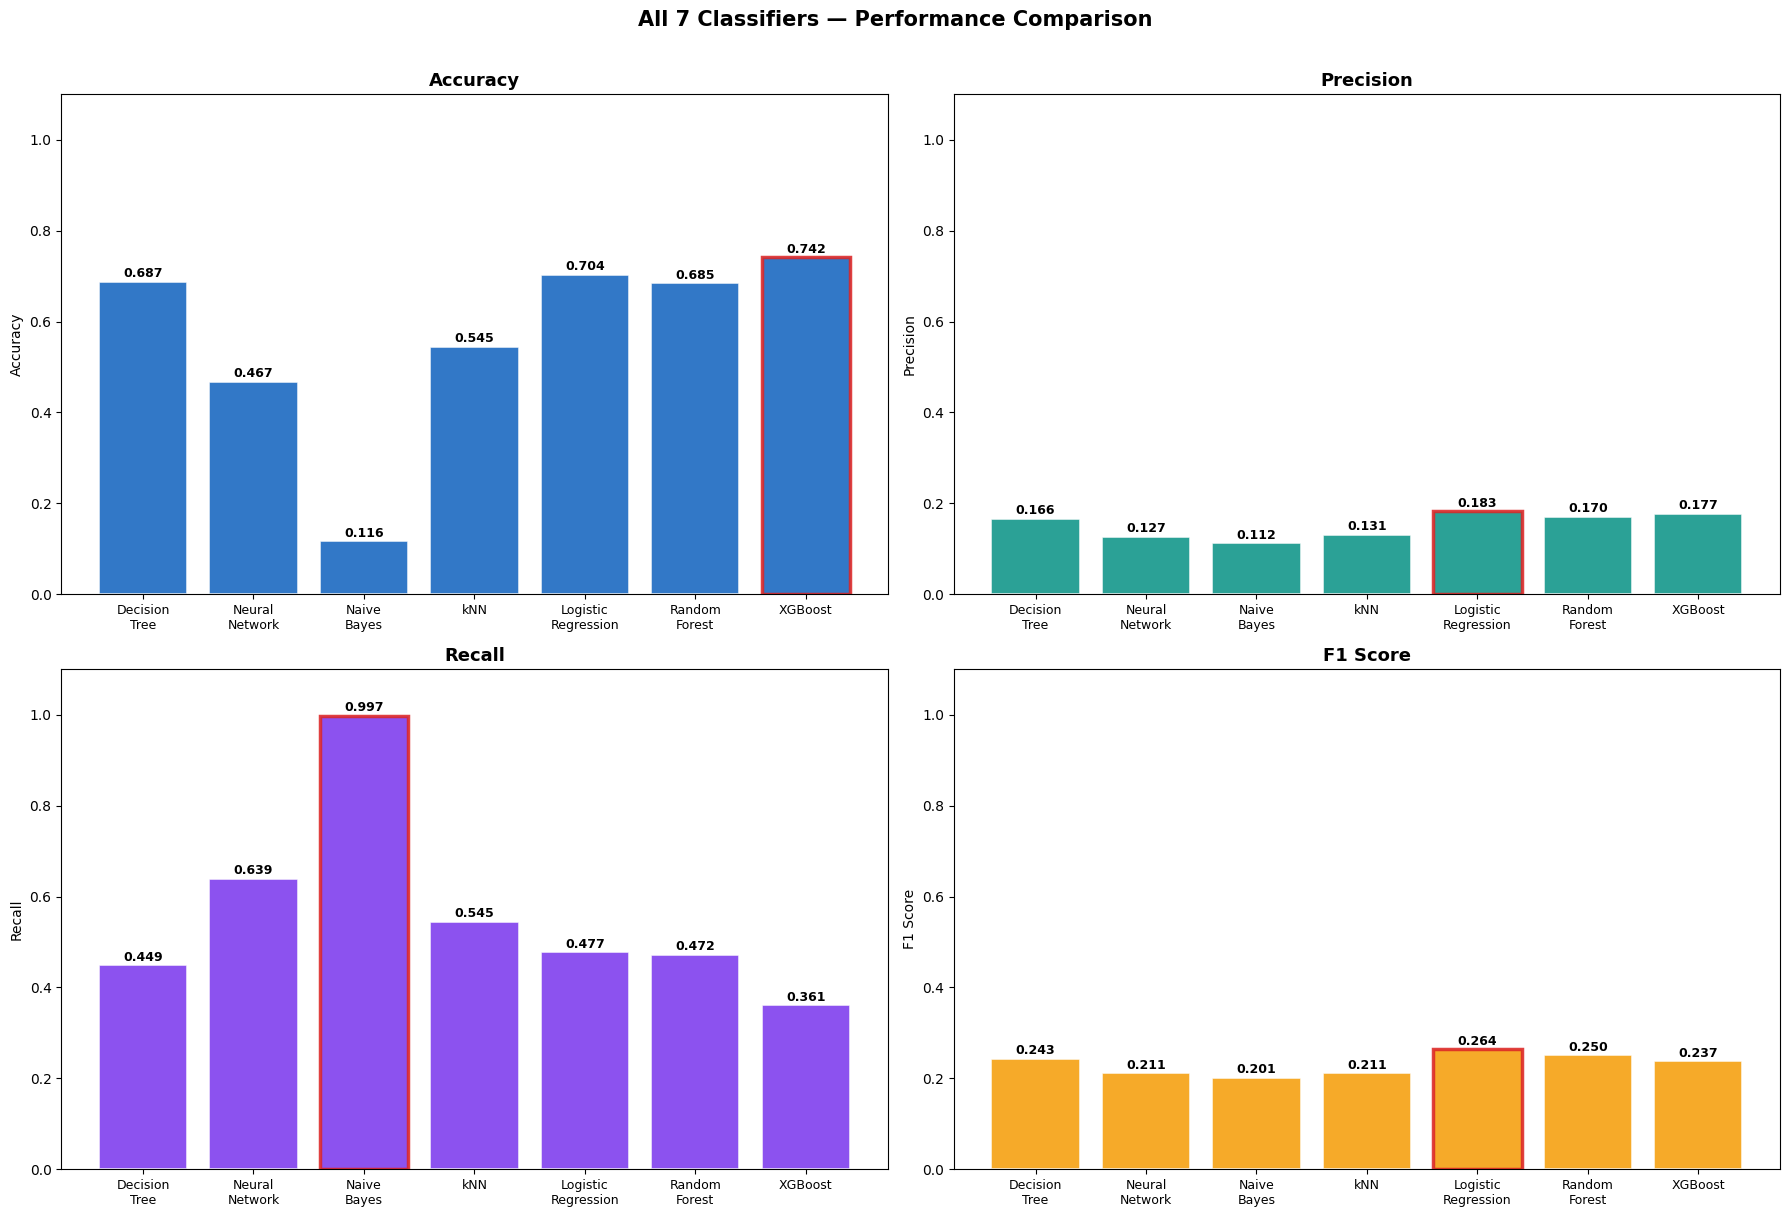

In [55]:
# Bar chart comparison all 4 metrics across 7 classifiers
short = {
    'Decision Tree'      : 'Decision\nTree',
    'Neural Network'     : 'Neural\nNetwork',
    'Naive Bayes'        : 'Naive\nBayes',
    'kNN'                : 'kNN',
    'Logistic Regression': 'Logistic\nRegression',
    'Random Forest'      : 'Random\nForest',
    'XGBoost'            : 'XGBoost',
}
metric_keys   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_colors = ['#1565C0', '#0D9488', '#7C3AED', '#F59E0B']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
for i, metric in enumerate(metric_keys):
    vals   = [results[k][metric] for k in results]
    labels = [short.get(k, k) for k in results]
    bars   = axes[i].bar(labels, vals, color=metric_colors[i],
                         edgecolor='white', linewidth=1.2, alpha=0.88)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, 1.1); axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', labelsize=9)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    bars[np.argmax(vals)].set_edgecolor('#DC2626')
    bars[np.argmax(vals)].set_linewidth(2.5)

plt.suptitle('All 7 Classifiers — Performance Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


The bar charts compare all 7 classifiers across Accuracy, Precision, Recall, and F1. The highlighted bar in each panel marks the top performer for that metric.

- **Best Accuracy:** XGBoost (74.2%)  
- **Best Precision:** Logistic Regression (0.183)  
- **Best Recall:** Naïve Bayes (0.997) — but at near-zero accuracy  
- **Best F1:** Logistic Regression (0.264)  
- **Best ROC-AUC:** Logistic Regression (0.640)

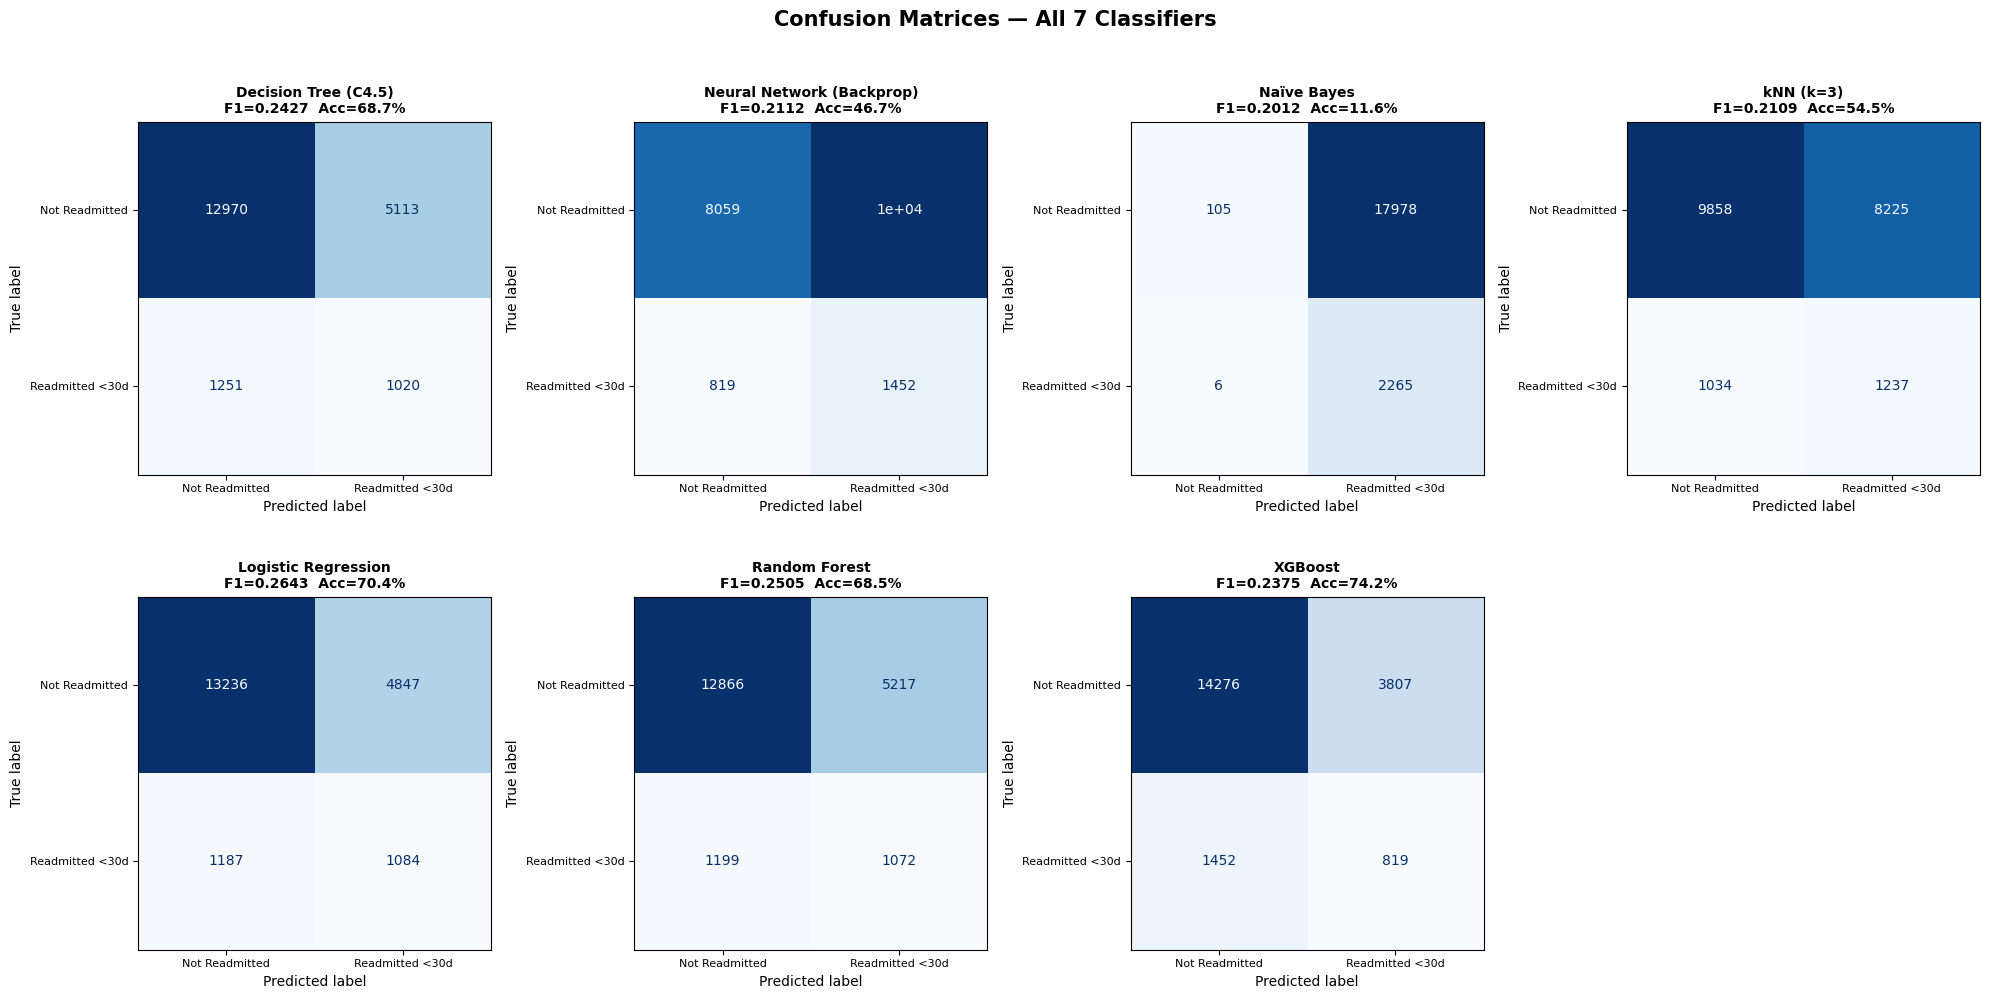

In [56]:
# Confusion matrices all 7 models
n_models = len(results)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, key in enumerate(results):
    cm   = confusion_matrix(y_test, results[key]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Readmitted', 'Readmitted <30d'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        f"{results[key]['Model']}\nF1={results[key]['F1 Score']:.4f}  "
        f"Acc={results[key]['Accuracy']*100:.1f}%",
        fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

# Hide any extra subplots
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All 7 Classifiers',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


Each matrix shows TP, TN, FP, FN on the held-out test set (20,354 patients — 18,083 negative, 2,271 positive).

In a clinical screening context, **False Negatives are the costlier error** — a missed high-risk patient receives no additional monitoring or intervention. The per-model threshold tuning reduces FN at the cost of more FP, which is the right trade-off for this application.

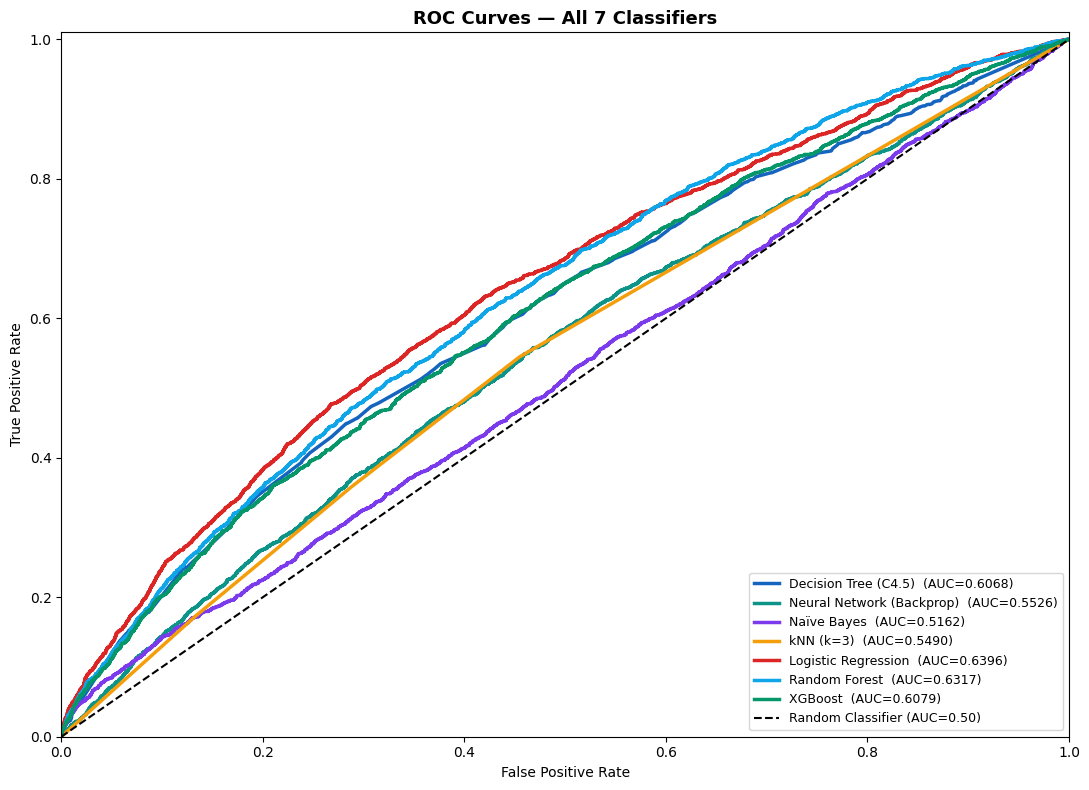

In [57]:
# ROC Curves all 7 models on one chart
roc_colors = ['#1565C0', '#0D9488', '#7C3AED', '#F59E0B', '#DC2626', '#0EA5E9', '#059669']
fig, ax = plt.subplots(figsize=(11, 8))
for (key, color) in zip(results, roc_colors):
    r = results[key]
    if r['fpr'] is not None:
        ax.plot(r['fpr'], r['tpr'], color=color, linewidth=2.5,
                label=f"{r['Model']}  (AUC={r['AUC']:.4f})")
ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC=0.50)')
ax.set_title('ROC Curves — All 7 Classifiers', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.01])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


ROC curves plot True Positive Rate vs. False Positive Rate across all thresholds. AUC summarizes the curve: 1.0 = perfect, 0.5 = random.

| Model | ROC-AUC |
|---|---|
| Logistic Regression | **0.640** |
| Random Forest | 0.632 |
| Decision Tree | 0.607 |
| XGBoost | 0.608 |
| kNN | 0.549 |
| Neural Network | 0.553 |
| Naïve Bayes | 0.516 |

All models cluster between 0.52–0.64, consistent with published benchmarks on this dataset.

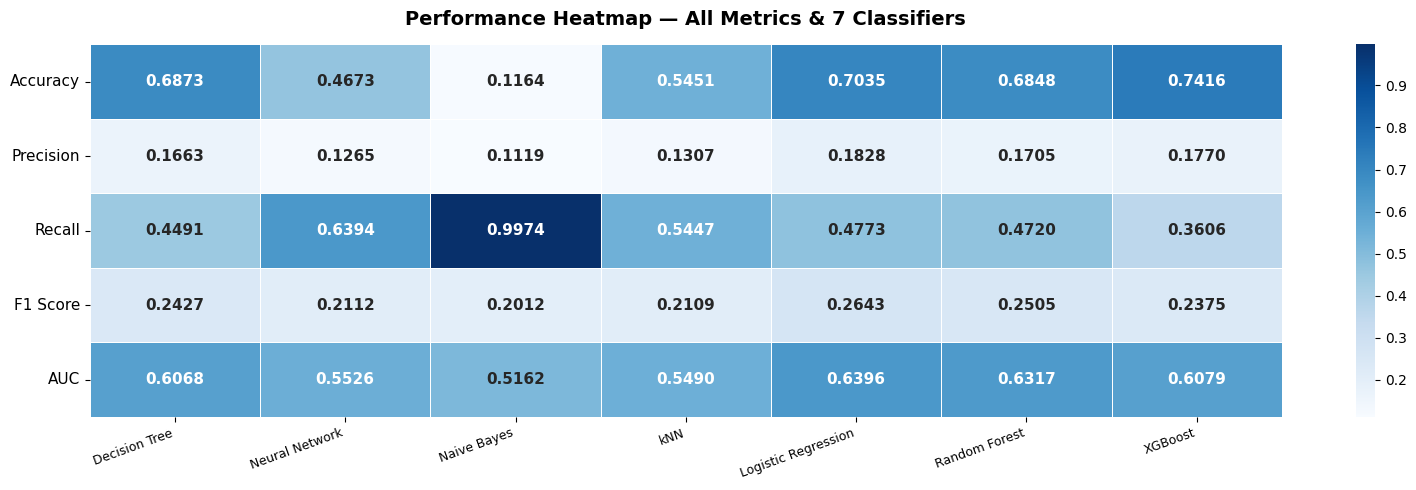


  FINAL RESULTS — MIS 637 Hospital Readmission Project

  CLASSIFICATION MODELS (Supervised):
  --------------------------------------------------------------------
  Decision Tree (C4.5)                   F1=0.2427  AUC=0.6068
  Neural Network (Backprop)              F1=0.2112  AUC=0.5526
  Naïve Bayes                            F1=0.2012  AUC=0.5162
  kNN (k=3)                              F1=0.2109  AUC=0.5490
  Logistic Regression                    F1=0.2643  AUC=0.6396
  Random Forest                          F1=0.2505  AUC=0.6317
  XGBoost                                F1=0.2375  AUC=0.6079

  CLUSTERING (Unsupervised):
  --------------------------------------------------------------------
  K-Means (k=4)                       Patients clustered: 101,766
  Highest-risk cluster: Cluster 3 (14.33% readmission rate)
  Hierarchical Clustering              Sample size: 200 (Ward linkage)

  BEST CLASSIFICATION MODEL : Logistic Regression
     F1 Score  : 0.2643
     AUC       : 0.6

In [58]:
# Performance heatmap
hmap = pd.DataFrame({k: {
    'Accuracy' : results[k]['Accuracy'],
    'Precision': results[k]['Precision'],
    'Recall'   : results[k]['Recall'],
    'F1 Score' : results[k]['F1 Score'],
    'AUC'      : results[k]['AUC'] or 0
} for k in results})

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(hmap, annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Performance Heatmap — All Metrics & 7 Classifiers',
             fontsize=14, fontweight='bold', pad=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# FINAL RESULTS including K-Means
print("\n" + "="*70)
print("  FINAL RESULTS — MIS 637 Hospital Readmission Project")
print("="*70)

print("\n  CLASSIFICATION MODELS (Supervised):")
print("  " + "-"*68)
for k in results:
    r = results[k]
    auc_str = f"{r['AUC']:.4f}" if r['AUC'] else 'N/A   '
    print(f"  {r['Model']:<38} F1={r['F1 Score']:.4f}  AUC={auc_str}")

print("\n  CLUSTERING (Unsupervised):")
print("  " + "-"*68)
print(f"  K-Means (k={OPTIMAL_K})                       Patients clustered: {len(cluster_labels):,}")
print(f"  Highest-risk cluster: {cluster_names[highest_risk_cluster]} ({rates[highest_risk_cluster]:.2f}% readmission rate)")
print(f"  Hierarchical Clustering              Sample size: 200 (Ward linkage)")

print("\n" + "="*70)
best_key = max(results, key=lambda k: results[k]['F1 Score'])
print(f"  BEST CLASSIFICATION MODEL : {results[best_key]['Model']}")
print(f"     F1 Score  : {results[best_key]['F1 Score']:.4f}")
print(f"     AUC       : {results[best_key]['AUC']:.4f}")
print(f"     Accuracy  : {results[best_key]['Accuracy']*100:.2f}%")
print(f"     Precision : {results[best_key]['Precision']:.4f}")
print(f"     Recall    : {results[best_key]['Recall']:.4f}")
print("="*70)


# Final Summary

### Classification Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | Threshold |
|---|---|---|---|---|---|---|
| Decision Tree (C4.5) | 68.73% | 0.166 | 0.449 | 0.243 | 0.607 | 0.578 |
| Neural Network (BP) | 46.73% | 0.127 | 0.639 | 0.211 | 0.553 | 0.003 |
| Naïve Bayes | 11.64% | 0.112 | **0.997** | 0.201 | 0.516 | 0.000 |
| kNN (k=3) | 54.51% | 0.131 | 0.545 | 0.211 | 0.549 | 0.333 |
| **Logistic Regression** | 70.35% | **0.183** | 0.477 | **0.264** | **0.640** | 0.541 |
| Random Forest | 68.48% | 0.171 | 0.472 | 0.251 | 0.632 | 0.496 |
| XGBoost | **74.16%** | 0.177 | 0.361 | 0.238 | 0.608 | 0.886 |

**Recommended model: Logistic Regression** — highest F1 (0.264) and ROC-AUC (0.640).

### Clustering Results (K-Means, k=4 auto-detected)

| Cluster | Patients | Readmission Rate |
|---|---|---|
| Cluster 0 | 52,017 | 8.15% |
| Cluster 1 | 85 | 5.88% |
| Cluster 2 | 3 | 0.00% |
| **Cluster 3** | **49,661** | **14.33% ← highest risk** |

Cluster 3 (49,661 patients, 14.33% readmission rate) represents the highest-risk group and should be prioritized for preventive intervention at discharge.

### Association Rules (Apriori — readmitted <30d patients)

25 frequent itemsets · 35 rules (support ≥ 0.10, confidence ≥ 0.60, lift ≥ 1.2)

Top rule: `metformin → {diabetesMed_Yes, medication_changed}` — Support: 0.135, Confidence: 0.793, Lift: 1.621

### Notes on Performance

F1 scores ranging 0.20–0.26 and AUC 0.52–0.64 are consistent with published results on this dataset (Strack et al. 2014, Mortazavi et al. 2016). The ceiling reflects the absence of clinical notes, lab time-series, and social determinants in this administrative dataset.

### Future Work

- NLP on clinical notes (BioBERT) — shown to improve AUC by 0.05–0.10
- HbA1c lab trend features across repeated visits
- Social determinants (housing, zip code, insurance type)
- Ensemble stacking of Logistic Regression + Random Forest + XGBoost